# SENDAs Agreement 1 Update 2010-2022 (Prediction, step 2.3, shap-informed models)

Quarto-specific YAML/options were preserved in the first raw cell. I also inserted setup cells at the beginning for project-root detection, loading `pred21_ndp_2026_03_26.Rdata`, plot sizing, and optional `renv` repair.


In [1]:
# --- Setup: project root, data load, plot size/resolution, and renv activation ---

# adjust plot size and resolution for high-quality output

# --- Load pred21_ndp_2026_03_26.Rdata (simple, project-root aware, no functions) --- 
# 1) Locate the file anywhere under the project root (current WD with a trailing "/cons" trimmed)
project_root <- sub("(/)?cons/?$", "", normalizePath(getwd(), winslash = "/", mustWork = FALSE))
fname        <- "pred21_ndp_2026_03_26.Rdata"
hits <- list.files(project_root, pattern = paste0("^", fname, "$"),
                   recursive = TRUE, full.names = TRUE, ignore.case = TRUE)

# If not found and path contains "Documents\GitHub\", try the data folder
if (!length(hits) && grepl("Documents[/\\\\]GitHub", project_root)) {
  alt_data_dir <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data")
  message("File not found in project root. Trying alternative data directory: ", alt_data_dir)
  hits <- list.files(alt_data_dir, pattern = paste0("^", fname, "$"),
                     recursive = TRUE, full.names = TRUE, ignore.case = TRUE)
}

if (!length(hits)) {
  stop("File not found: ", fname, 
       "\nSearched under: ", project_root,
       "\nAnd under: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data"))
}
path <- hits[1]  # take first match
message("Loading: ", path)

# 2) Load into a dedicated environment (keeps .GlobalEnv clean)
env_pred <- new.env(parent = emptyenv())
loaded_objects <- load(path, envir = env_pred)
message("Loaded ", length(loaded_objects), " object(s): ", paste(loaded_objects, collapse = ", "))

# 3) Quick sanity check for each loaded object
for (obj_name in loaded_objects) {
  obj <- get(obj_name, envir = env_pred)
  message("\n--- ", obj_name, " ---")
  if (is.data.frame(obj)) {
    message("Rows: ", nrow(obj), " | Cols: ", ncol(obj))
  } else {
    message("Class: ", paste(class(obj), collapse = ", "), " | Length/Size: ", length(obj))
  }
  # print(str(obj))
}

# 4) Extract all loaded objects to global environment
for (obj_name in loaded_objects) {
  assign(obj_name, get(obj_name, envir = env_pred), envir = .GlobalEnv)
}

# Clean up temporary environment
rm(env_pred)

options(jupyter.max_output_size = Inf)
options(repr.plot.width = 16 * 1.5, repr.plot.height = 12 * 1.5)
options(repr.plot.res = 300)

# --- renv activation with fallback ---
Sys.setenv(RENV_PROJECT = project_root)

# Try project_root renv first, then fallback to Documents/GitHub/renv
renv_activate <- file.path(project_root, "renv/activate.R")
if (!file.exists(renv_activate)) {
  # Fallback: construct path from USERPROFILE environment variable
  fallback_root <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub")
  renv_activate <- file.path(fallback_root, "renv/activate.R")
  
  if (file.exists(renv_activate)) {
    message("Project renv not found. Using fallback renv at: ", renv_activate)
    Sys.setenv(RENV_PROJECT = fallback_root)
  } else {
    stop("renv/activate.R not found at project root nor at fallback location: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/renv/activate.R"))
  }
}

source(renv_activate)

getwd()
Sys.getenv("RENV_PROJECT")
.libPaths()

Loading: C:/Users/nDP/Documents/GitHub/data/20241015_out/pred21_ndp_2026_03_26.Rdata
Loaded 281 object(s): infectious_set, find_latest_file, cal_readmit2, mode_pick_int, cal_readmit3, python_columns, nm, cal_death_full_ici, collapse_first_sub_used_other, .cph_boot_extract_ibs, char_variables, secret_file_path, cols_to_exclude, total_cpus, decrypt_column, n1b_cases, api_key, plot_cloglog_comb, encrypt_column, renviron_path, .mi_cv_build_level_mapping, subkey_to_label, hits, missing_pct, target_cols, py_split, aicc_death_upd2, dummy_formula, apply_ordered_mappings, t_grid, cif_d_before, m4_cases, calibrate_cph_grouped, m3_runs, violations, ph_test_death, root, ci_first, cal_readmit, existing_lines, obj, .Random.seed, n_before, results_readmit2_ibs, formula_readmit_updated2, decrypt_chr, DUMMY_REFERENCE, .mi_cv_normalize_call_name, pairs, key_exists, encrypt_chr, sum_dates_polars, normalize_txt, find_python_rel, .mi_cv_collect_strata_term_labels, time_before_dedup2, numerical_vars2, lab_f

[1] "C:/Users/nDP/Documents/GitHub/renv/library/windows/R-4.4/x86_64-w64-mingw32"                
[2] "C:/Users/nDP/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43"

In [2]:
# Function to handle renv environment loading based on working directory rules
load_custom_renv <- function() {
  # Get current working directory
  wd <- getwd()
  
  # Normalize to lowercase for case-insensitive matching
  wd_lower <- tolower(wd)
  
  # Rule 1: If path contains "mi unidad" or "my drive"
  if (grepl("mi unidad", wd_lower) || grepl("my drive", wd_lower)) {
    message("Rule 1: Path is inside Google Drive. Keeping current environment.")
    
  # Rule 2: If path contains "cons"
  } else if (grepl("cons", wd_lower)) {
    parent_dir <- dirname(wd)
    lockfile <- file.path(parent_dir, "renv.lock")
    
    # Rule 3: Check if renv.lock exists in parent directory
    if (file.exists(lockfile)) {
      message("Rule 3: Found renv.lock in parent directory. Restoring environment...")
      renv::restore(lockfile = lockfile, exclude= "polars")
    } else {
      message("Rule 3: No renv.lock found in parent directory. No restore performed.")
    }
    
  # Default case: Path does not match any rule
  } else {
    message("Default: Path does not match rules. Keeping current environment.")
  }
}

# Example usage:
load_custom_renv()


Rule 3: Found renv.lock in parent directory. Restoring environment...
- The library is already synchronized with the lockfile.


In [3]:
# --- Optional renv cleanup / repair ---
# Run this only if you actually need to repair the project library.

unlink("renv/staging", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/geepack", recursive = TRUE, force = TRUE)
unlink("renv/library/windows/R-4.4/x86_64-w64-mingw32/V8", recursive = TRUE, force = TRUE)

renv::status()
#renv::restore(exclude = c("polars"))

The following package(s) are used in this project, but are not installed:
- geepack

See `?renv::status` for advice on resolving these issues.


<style type="text/css">
.showopt {
background-color: #004c93; color: #FFFFFF; width: 100px; height: 20px; text-align: center; vertical-align: middle !important; float: right; font-family: sans-serif; border-radius: 8px;
}
.showopt:hover {
background-color: #dfe4f2;
color: #004c93;
}
pre.plot {
background-color: white !important;
}
.tablelines table, .tablelines td, .tablelines th {
border: 1px solid black;
}
.centrado {
text-align: center;
}
.table.center {
margin-left:auto;
margin-right:auto;
}
/* https://vivekjaiskumar.medium.com/css-is-and-not-selector-17c942ec83f :is()*/
/* Applies to outputs that are not code other than R*/
pre {
overflow-x: auto !important;
}
pre code {
word-wrap: normal !important;
white-space: pre !important;
}
/*
pre:not(.sourceCode) {
white-space: nowrap !important;
}
*/
.sourceCode { /* Important gives precedence */
font-size: 10px !important;
line-height: 50% !important;
}
body{ /* Normal */
text-align: justify;
}
.superbigimage{
overflow-y:scroll;
height:350px;
white-space: nowrap;
overflow-x: auto;
width:100%;
}
.superbigimage img{
overflow-y: scroll;
overflow-x: hidden;
}
.message { color:#446C6E; font-family: monospace;font-size: 10px; line-height: 110%; font-weight: bold;}
div.blue { background-color:#e6f0ff; border-radius: 5px; padding: 5px; text-align: justify;}
div.red { background-color:#e6bab1; border-radius: 5px; padding: 5px; text-align: justify;}
.pandoc-table { /* Should add !important; but it seems no necessary */
margin-left:auto; /* To center */
margin-right:auto;
border-collapse: collapse;
table-layout: auto;
font-size: 11px;
overflow-y: auto;
max-height:450px !important;
white-space: nowrap;
overflow-x: auto;
width:450px;
}
.pandoc-table th {/* header */
text-align: center !important;
font-size: 10px;
padding: 0px;
}
.pandoc-table td {
text-align: left !important;
font-size: 9px;
padding: 0px;
}
.pandoc-table caption {
text-align: left !important;
font-size: 11px !important;
}
.center-table {
text-align: left !important;
font-size: 9px;
overflow-y:scroll;
height:450px;
overflow-x: scroll;
}
.controlly{
overflow-y:scroll;
height:350px;
overflow-x: scroll;
}
/*2025-03-07*/
.callout-warning,
.callout-error,
.callout-message {
  font-size: 0.7rem !important;  /* Adjust this value as needed */
}
.alert, .message {
    font-size: 0.7em !important;
}
.alert.alert-warning,
.alert.alert-danger,
.message {
    font-size: 0.7em !important;
}
</style>


<style>
#| label: css-format
h1 {
    color: var(--heading-color);
    font-size: 2rem;
    margin-bottom: 1vh;
}
p {
  font-size: 1.1rem;
  line-height: 1.6rem;
}
a {
  color: var(--primary-color);
  text-decoration: none;
  border-bottom: 3px solid transparent;
  font-weight: bold;
  &:hover, &:focus {
      border-bottom: 3px solid currentColor;
  }
}
section {
  margin: 0 auto;
}
.post-meta {
  font-size: 1rem;
  font-style: italic;
  display: block;
  margin-bottom: 4vh;
  color: var(--secondary-color);
}
nav {
  display: flex;
  justify-content: flex-end;
  padding: 20px 0;
}
/*slider switch css */
.theme-switch-wrapper {
  display: flex;
  align-items: center;
  
  em {
    margin-left: 10px;
    font-size: 1rem;
  }
}
.theme-switch {
  display: inline-block;
  height: 34px;
  position: relative;
  width: 60px;
}
.theme-switch input {
  display:none;
}
.slider {
  background-color: #ccc;
  bottom: 0;
  cursor: pointer;
  left: 0;
  position: absolute;
  right: 0;
  top: 0;
  transition: .4s;
}
.slider:before {
  background-color: #fff;
  bottom: 4px;
  content: "";
  height: 26px;
  left: 4px;
  position: absolute;
  transition: .4s;
  width: 26px;
}
input:checked + .slider {
  background-color: #66bb6a;
}
input:checked + .slider:before {
  transform: translateX(26px);
}
.slider.round {
  border-radius: 34px;
}
.slider.round:before {
  border-radius: 50%;
}
</style>


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [ ]:
#| label: setup
#| results: "hold"
#renv falls back to copying rather than symlinking, which is evidently very slow in this configuration.
renv::settings$use.cache(FALSE)
#only use explicit dependencies (in DESCRIPTION)
renv::settings$snapshot.type("implicit")
#check if rstools is installed
if(Sys.info()["sysname"]=="Windows"){
try(installr::install.Rtools(check_r_update=F))
}
check_quarto_version <- function(required = "1.7.29", comparator = c("ge","gt","le","lt","eq")) {
  comparator <- match.arg(comparator)
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req     <- package_version(required)
  ok <- switch(comparator,
               ge = current >= req,
               gt = current >  req,
               le = current <= req,
               lt = current <  req,
               eq = current == req)
  if (!ok) {
    stop(sprintf("Quarto version check failed: need %s %s (installed: %s).",
                 comparator, required, current), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge") 
#change repository to CL
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos=r)
})
if(!require(pacman)){install.packages("pacman");require(pacman)}
if(!require(pak)){install.packages("pak");require(pak)}
pacman::p_unlock(lib.loc = .libPaths()) #para no tener problemas reinstalando paquetes
if(Sys.info()["sysname"]=="Windows"){
if (getRversion() != "4.4.1") { stop("Requires R version 4.4.1; Actual: ", getRversion()) }
}
#check docker
check_docker_running <- function() {
  # Try running 'docker info' to check if Docker is running
  system("docker info", intern = TRUE, ignore.stderr = TRUE)
}
if(Sys.info()["sysname"]=="Windows"){
  install_docker <- function() {
    # Open the Docker Desktop download page in the browser for installation
    browseURL("https://www.docker.com/products/docker-desktop")
  }
  # Main logic
  if (inherits(try(check_docker_running(), silent = TRUE), "try-error")) {
    liftr::install_docker()
  } else {
    message("Docker is running.")
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#PACKAGES#######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
unlink("*_cache", recursive=T)
pak::pak_sitrep()
# pak::sysreqs_check_installed(unique(unlist(paks)))
#pak::lockfile_create(unique(unlist(paks)),  "dependencies_duplicates24.lock", dependencies=T)
#pak::lockfile_install("dependencies_duplicates24.lock")
#https://rdrr.io/cran/pak/man/faq.html
#pak::cache_delete()
library(tidytable)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(future)
library(future.apply)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)
library(knitr)

#flexsurv
#if(!require(compareCstat)){install.pacakges("compareCstat")}
# library(shapr)#https://norskregnesentral.github.io/shapr/
# library(SemiMarkov)#https://www.degruyterbrill.com/document/doi/10.1515/ijb-2020-0083/html?lang=en
# #https://www.jclinepi.com/article/S0895-4356(24)00142-2/fulltext
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 3. Activate polars code completion (safe to try even if it fails)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
#try(polars_code_completion_activate())
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 4. BPMN from GitHub (not on CRAN, so install via devtools if missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
if (!requireNamespace("bpmn", quietly = TRUE)) {
  devtools::install_github("bergant/bpmn")
}
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# 5. PhantomJS Check (use webshot if PhantomJS is missing)
#_#_#_#_#_#_#_#_#_#_#_#_#_-----------------------------
# if (!webshot::is_phantomjs_installed()) {
#   webshot::install_phantomjs()
# }
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
pander::panderOptions('big.mark', ',')
pander::panderOptions('decimal.mark', '.')
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#to format rows in bold
format_cells <- function(df, rows ,cols, value = c("italics", "bold", "strikethrough")){
  # select the correct markup
  # one * for italics, two ** for bold
  map <- setNames(c("*", "**", "~~"), c("italics", "bold", "strikethrough"))
  markup <- map[value]  
  for (r in rows){
    for(c in cols){
      # Make sure values are not factors
      df[[c]] <- as.character( df[[c]])
      # Update formatting
      df[r, c] <- ifelse(nchar(df[r, c])==0,"",paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
  }
  return(df)
}
#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
sum_dates <- function(x){
  cbind.data.frame(
    min= as.Date(min(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01"),
    p001= as.Date(quantile(unclass(as.Date(x)), .001, na.rm=T), origin = "1970-01-01"),
    p005= as.Date(quantile(unclass(as.Date(x)), .005, na.rm=T), origin = "1970-01-01"),
    p025= as.Date(quantile(unclass(as.Date(x)), .025, na.rm=T), origin = "1970-01-01"),
    p25= as.Date(quantile(unclass(as.Date(x)), .25, na.rm=T), origin = "1970-01-01"),
    p50= as.Date(quantile(unclass(as.Date(x)), .5, na.rm=T), origin = "1970-01-01"),
    p75= as.Date(quantile(unclass(as.Date(x)), .75, na.rm=T), origin = "1970-01-01"),
    p975= as.Date(quantile(unclass(as.Date(x)), .975, na.rm=T), origin = "1970-01-01"),
    p995= as.Date(quantile(unclass(as.Date(x)), .995, na.rm=T), origin = "1970-01-01"),
    p999= as.Date(quantile(unclass(as.Date(x)), .999, na.rm=T), origin = "1970-01-01"),
    max= as.Date(max(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01")
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Define the function adapted for Polars
sum_dates_polars <- function(df, date_col) {
  # Create the list of quantiles
  quantiles <- c(0.001, 0.005, 0.025, 0.25, 0.5, 0.75, 0.975, 0.995, 0.999)
  # Create expressions to calculate min and max
  expr_list <- list(
    pl$col(date_col)$min()$alias("min"),
    pl$col(date_col)$max()$alias("max")
  )
  # Add expressions for quantiles
  for (q in quantiles) {
    expr_list <- append(expr_list, pl$col(date_col)$quantile(q)$alias(paste0("p", sub("\\.", "", as.character(q)))))
  }
  # Apply the expressions and return a DataFrame with the results
  df$select(expr_list)
}
# Custom function for sampling with a seed
sample_n_with_seed <- function(data, size, seed) {
  set.seed(seed)
  dplyr::sample_n(data, size)
}
# Function to get the most frequent value 
most_frequent <- function(x) { 
  uniq_vals <- unique(x)
  freq_vals <- sapply(uniq_vals, function(val) sum(x == val))
  most_freq <- uniq_vals[which(freq_vals == max(freq_vals))]
  
  if (length(most_freq) == 1) {
    return(most_freq)
  } else {
    return(NA)
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#CONFIG #######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
options(scipen=2) #display numbers rather scientific number
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# Define the function first
#joins these values with semicolons and optionally truncates the result if it exceeds a specified width.
toString2 <- function(x, width = NULL, ...) {
    string <- paste(x, collapse = "; ")
    if (missing(width) || is.null(width) || width == 0) 
        return(string)
    if (width < 0) 
        stop("'width' must be positive")
    if (nchar(string, type = "w") > width) {
        width <- max(6, width)
        string <- paste0(substr(string, 1, width - 3), "...")
    }
    string
}
normalize_txt <- function(x) {
  x|>
    stringi::stri_trans_general("Latin-ASCII")|>
    tolower()|>
    trimws()
}
pair_str <- function(main, sub) {
  main <- as.character(main)
  sub  <- as.character(sub)
  both_na <- is.na(main) & is.na(sub)
  out <- paste0(
    tidytable::coalesce(main, "NA"),
    "::",
    tidytable::coalesce(sub,  "NA")
  )
  out[both_na] <- NA_character_
  out
}
# ── Helpers ────────────────────────────────────────────────────────────
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Encryption ────────────────────────────────────────────────────────
# Pack: [24-byte nonce][ciphertext] -> hex
encrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        ct <- sodium::data_encrypt(charToRaw(as.character(v)), key)
        nonce <- attr(ct, "nonce")                 # 24 bytes
        sodium::bin2hex(c(nonce, ct))              # pack nonce + ct
    }, FUN.VALUE = character(1))
}
# Unpack: hex -> [nonce|ciphertext], restore attr(nonce), then decrypt
decrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        buf <- sodium::hex2bin(v)
        if (length(buf) < 25L) stop("Ciphertext too short or corrupted.")
        nonce <- buf[1:24]
        ct    <- buf[-(1:24)]
        attr(ct, "nonce") <- nonce
        rawToChar(sodium::data_decrypt(ct, key))
    }, FUN.VALUE = character(1))
}
# Function to encrypt a character vector
encrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item) || item == "") {
      return(NA_character_)
    }
    encrypted_raw <- sodium::data_encrypt(charToRaw(item), key)
    base64enc::base64encode(encrypted_raw)  # Convert to base64 for storage
  }, USE.NAMES = FALSE)
}
decrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item)) return(NA_character_)
    encrypted_raw <- base64enc::base64decode(item)
    rawToChar(sodium::data_decrypt(encrypted_raw, key))
  }, USE.NAMES = FALSE)
}
is_stata_ok <- function(x) {
  nchar(x) <= 32 & grepl("^[A-Za-z][A-Za-z0-9_]*$", x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# ── Tidy RMS ────────────────────────────────────────────────────────
tidy_cph <- function(model) {
  if (!inherits(model, "cph")) stop("Model must be an rms::cph object")
  
  # run summary
  s <- summary(model)
  df_s <- as.data.frame(unclass(s))
  df_s$rown <- rownames(s)
  
  # find rows that are "Hazard Ratio"
  hr_rows <- trimws(df_s$rown) == "Hazard Ratio"
  
  # build tidy tibble
  tibble::tibble(
    term     = trimws(rownames(s)[which(hr_rows) - 1L]), # previous row = variable name
    estimate = df_s$Effect[hr_rows],                     # Hazard Ratio
    conf.low = df_s$`Lower 0.95`[hr_rows],
    conf.high= df_s$`Upper 0.95`[hr_rows],
    p.value  = df_s$P[hr_rows]
  )
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:

find_latest_file <- function(project_root, prefix, extension = "csv") {
  # Construct the regex pattern using the provided extension.
  # We use \\. to match the literal dot before the extension.
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.", extension, "$")
  # List files matching the pattern recursively under the project root
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE,
    recursive = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern, "under", project_root))
  }
  # Helper to extract timestamps from filenames (expected format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    # Use the last match in case there are multiple date-like strings in the path
    return(matches[[1]][length(matches[[1]])])
  }
  # Compute timestamps for all found files
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in the matching filenames.")
  }
    # Sort by timestamp (descending) and return the latest file path
  # Lexicographical sorting works correctly for YYYYMMDD_HHMM format
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

Installing package into ‘C:/Users/nDP/Documents/GitHub/renv/library/windows/R-4.4/x86_64-w64-mingw32’
(as ‘lib’ is unspecified)


trying URL 'https://packagemanager.posit.co/cran/latest/bin/windows/contrib/4.4/pkgbuild_1.4.8.zip'
Content type 'binary/octet-stream' length 211749 bytes (206 KB)
downloaded 206 KB



package ‘pkgbuild’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\nDP\AppData\Local\Temp\RtmpKUSW8D\downloaded_packages
Loading required package: pkgbuild
No need to install Rtools - You've got the relevant version of Rtools installed
Loading required package: pacman
Loading required package: pak

No 00LOCK detected in:
 C:/Users/nDP/Documents/GitHub/renv/library/windows/R-4.4/x86_64-w64-mingw32
No 00LOCK detected in:
 C:/Users/nDP/AppData/Local/R/cache/R/renv/sandbox/windows/R-4.4/x86_64-w64-mingw32/e0da0d43
Please follow the instructions on https://docs.docker.com/docker-for-windows/install/ 
to install Docker for Windows (admin privileges required).
Please use check_docker() after installation to see if Docker was detectable.* pak version:
- 0.8.0.1
* Version information:
- pak platform: x86_64-w64-mingw32 (current: x86_64-w64-mingw32, compatible)
- pak repository: - (local install?)
* Optional packages installed:
- pillar
* Library path:

In [5]:
root <- here::here()

project_root <- gsub("/cons*", "", root) 

data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")
project_root

[1] "C:/Users/nDP/Documents/GitHub"


<br>

::: {.callout-note}
**Aims**
- To identify key prognostic and predictive factors associated with the risk of, and time to, the first readmission to treatment among patients aged 18-64 undergoing initial treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
- To identify key prognostic and predictive factors associated with the risk of, and time to, all-cause mortality among the same cohort of patients undergoing initial treatment for SUD in Chile.
- To predict the risk and timing of first treatment readmission and all-cause mortality simultaneously, treating these outcomes within a semi-competing risks framework. This will allow for the estimation of cumulative incidence for each event in the presence of the other for patients aged 18-64 who initiated SUD treatment in Chile between 2010 and 2020.
This study has three primary objectives. First, we aim to identify key prognostic and predictive factors associated with the risk and timing of two critical outcomes: (i) first readmission to treatment and (ii) all-cause mortality. Second, using a semi-competing risks framework, we will develop a model to simultaneously predict these two outcomes, accounting for the fact that death precludes the possibility of readmission. Finally, this model will be used to estimate the probability of various patient trajectories over time following initial treatment. The study population includes all patients aged 18-64 who began treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
:::
<br>



In [6]:
#| label: cpu-def

gc()

total_cpus <- parallel::detectCores()

cpus <- ifelse(total_cpus > 30, 16, 8)
paste0("Of the total ", total_cpus, " CPUs, we used ", cpus)

[1] "Of the total 32 CPUs, we used 16"

In [7]:
#| label: shap-criteria-setup-var-influence

predictor_tiers <- readxl::read_excel(
  file.path(project_root, "cons", "_out",
            "ds63_dual_predictor_analysis_no_clinical_20260404_1433.xlsx"),
  sheet = "Predictors"
) |>
  dplyr::filter(!grepl("MINOR",importance_tier))


predictor_tiers |> dplyr::arrange(desc(outcome)) |> knitr::kable(
  caption = "Predictor tiers based on SHAP importance from DeepSurv models"
)




Table: Predictor tiers based on SHAP importance from DeepSurv models

|outcome     |feature                                       | mean_abs_shap_risk| max_abs_shap_risk| mean_rank| rank_ci2p5| rank_ci97p5| horizon_count| freq_in_top_15_pct| freq_in_top_5_pct| rank| rel_to_max_pct|importance_tier       |stability_label |stable_freq_ge_75pct |direction_method     | delta_point| delta_ci_low| delta_ci_high| direction_n|direction_label |
|:-----------|:---------------------------------------------|------------------:|-----------------:|---------:|----------:|-----------:|-------------:|------------------:|-----------------:|----:|--------------:|:---------------------|:---------------|:--------------------|:--------------------|-----------:|------------:|-------------:|-----------:|:---------------|
|Readmission |primary_sub_mod_cocaine_paste                 |          0.1301747|         0.1301747|         1|          1|           1|             6|                100|               100|

In [8]:
#| label: shap-criteria-spec

gc()

options(future.globals.maxSize = 8L * 1024^3)  # 8 GiB

vars_shap_ds_r <- c(
  "primary_sub_mod_cocaine_paste",
  #"plan_type_corr_pg_pr", # maintained in the model as strata(plan_type_strata)
  "sex_rec_woman",
  "ethnicity",
  "adm_age_rec3",
  "primary_sub_mod_cocaine_powder",
  #"eva_consumo", # grouped term in selection; represented below with available dummies
  "eva_consumo_logro_intermedio",
  "eva_consumo_logro_minimo",
  #"plan_type_corr_m_pr", # maintained in the model as strata(plan_type_strata)
  #"ed_attainment_corr", # grouped term in selection; represented below with available dummies
  "ed_attainment_corr_2_completed_high_school_or_less",
  "ed_attainment_corr_3_completed_primary_school_or_less",
  "dg_psiq_cie_10_dg",
  #"eva_sm", # grouped term in selection; represented below with available dummies
  "eva_sm_logro_intermedio",
  "eva_sm_logro_minimo",
  "dit_m",
  "occupation_condition_corr24_unemployed",
  "tr_outcome_adm_discharge_rule_violation_undet",
  "polysubstance_strict",
  "tr_outcome_dropout", # not in top 15%
  "primary_sub_mod_alcohol", # not in top 15%
  "tr_outcome_referral", # not in top 15%
  "cohabitation_with_couple_children", # not in top 15%
  "sub_dep_icd10_status_drug_dependence", # not in top 15%
  #"eva_relinterp", # grouped term in selection; represented below with available dummies
  "eva_relinterp_logro_intermedio", # not in top 15%
  "eva_relinterp_logro_minimo", # not in top 15%
  "porc_pobr", # not in top 15%
  #"prim_sub_freq_rec", # grouped term in selection; represented below with available dummies
  "prim_sub_freq_rec_2_2_6_days_wk", # not in top 15%
  "prim_sub_freq_rec_3_daily", # not in top 15%
  "cohabitation_family_of_origin", # not in top 15%
  "adm_motive_justice_sector", # not in top 15%
  "first_sub_used_alcohol", # not in top 15%
  "any_violence_1_domestic_violence_sex_abuse", # not in top 15%
  "marital_status_rec_single", # not in top 15%
  #"eva_transgnorma", # grouped term in selection; represented below with available dummies
  "eva_transgnorma_logro_intermedio", # not in top 15%
  "eva_transgnorma_logro_minimo", # not in top 15%
  "dg_psiq_cie_10_instudy", # not in top 15%
  #"tenure_status_household", # grouped term in selection; represented below with available dummies
  "tenure_status_household_renting", # not in top 15%
  "tenure_status_household_others", # not in top 15%
  "tenure_status_household_stays_temporarily_with_a_relative", # not in top 15%
  "tenure_status_household_illegal_settlement", # not in top 15%
  "any_phys_dx", # not in top 15%
  #"eva_ocupacion", # grouped term in selection; represented below with available dummies
  "eva_ocupacion_logro_intermedio", # not in top 15%
  "eva_ocupacion_logro_minimo", # not in top 15%
  #"plan_type_corr_pg_pai", # maintained in the model as strata(plan_type_strata)
  #"eva_fam", # grouped term in selection; represented below with available dummies
  "eva_fam_logro_intermedio", # not in top 15%
  "eva_fam_logro_minimo", # not in top 15%
  #"eva_fisica", # grouped term in selection; represented below with available dummies
  "eva_fisica_logro_intermedio", # not in top 15%
  "eva_fisica_logro_minimo", # not in top 15%
  "adm_motive_sanitary_sector", # not in top 15%
  #"evaluacindelprocesoteraputico", # grouped term in selection; represented below with available dummies
  "evaluacindelprocesoteraputico_logro_intermedio", # not in top 15%
  "evaluacindelprocesoteraputico_logro_minimo", # not in top 15%
  #"urbanicity_cat", # grouped term in selection; represented below with available dummies
  "urbanicity_cat_2_mixed", # not in top 15%
  "urbanicity_cat_1_rural" # not in top 15%
)

vars_shap_ds_d <- c(
  "adm_age_rec3",
  "primary_sub_mod_alcohol",
  "occupation_condition_corr24_unemployed",
  "any_phys_dx",
  #"prim_sub_freq_rec", # grouped term in selection; represented below with available dummies
  "prim_sub_freq_rec_2_2_6_days_wk",
  "prim_sub_freq_rec_3_daily",
  "cohabitation_with_couple_children",
  #"eva_ocupacion", # grouped term in selection; represented below with available dummies
  "eva_ocupacion_logro_intermedio",
  "eva_ocupacion_logro_minimo",
  #"eva_fisica", # grouped term in selection; represented below with available dummies
  "eva_fisica_logro_intermedio",
  "eva_fisica_logro_minimo",
  "sex_rec_woman",
  "tr_outcome_adm_discharge_rule_violation_undet",
  "occupation_condition_corr24_inactive",
  "adm_motive_sanitary_sector",
  "polysubstance_strict",
  #"eva_sm", # grouped term in selection; represented below with available dummies
  "eva_sm_logro_intermedio",
  "eva_sm_logro_minimo",
  #"ed_attainment_corr", # grouped term in selection; represented below with available dummies
  "ed_attainment_corr_2_completed_high_school_or_less",
  "ed_attainment_corr_3_completed_primary_school_or_less",
  "first_sub_used_alcohol", # not in top 15%
  "primary_sub_mod_cocaine_paste", # not in top 15%
  "dg_psiq_cie_10_instudy" # not in top 15%
)
formula_shap_ds_readmit <- as.formula(
  paste("Surv(readmit_time_from_disch_m, readmit_event) ~", 
        paste(vars_shap_ds_r, collapse = " + "), "+ strata(plan_type_strata)")
)
formula_shap_ds_death <- as.formula(
  paste("Surv(death_time_from_disch_m, death_event) ~", 
        paste(vars_shap_ds_d, collapse = " + "), "+ strata(plan_type_strata)")
)

In [9]:
formula_shap_ds_readmit

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    sex_rec_woman + ethnicity + adm_age_rec3 + primary_sub_mod_cocaine_powder + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + tr_outcome_adm_discharge_rule_violation_undet + 
    polysubstance_strict + tr_outcome_dropout + primary_sub_mod_alcohol + 
    tr_outcome_referral + cohabitation_with_couple_children + 
    sub_dep_icd10_status_drug_dependence + eva_relinterp_logro_intermedio + 
    eva_relinterp_logro_minimo + porc_pobr + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_family_of_origin + 
    adm_motive_justice_sector + first_sub_used_alcohol + any_violence_1_domestic_violence_sex_abuse + 
    marital_status_rec

In [10]:
formula_shap_ds_death

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_alcohol + 
    occupation_condition_corr24_unemployed + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_with_couple_children + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    tr_outcome_adm_discharge_rule_violation_undet + occupation_condition_corr24_inactive + 
    adm_motive_sanitary_sector + polysubstance_strict + eva_sm_logro_intermedio + 
    eva_sm_logro_minimo + ed_attainment_corr_2_completed_high_school_or_less + 
    ed_attainment_corr_3_completed_primary_school_or_less + first_sub_used_alcohol + 
    primary_sub_mod_cocaine_paste + dg_psiq_cie_10_instudy + 
    strata(plan_type_strata)

In [11]:
#| label: shap-criteria-source-python-style-dual-cox-eval

source(paste0(project_root,"/cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R"))

In [12]:
#| label: shap-criteria-run-ev-mi-cv

cat("Removing collineal variable\n")
formula_shap_ds_readmit_clean <- as.formula(
  paste(gsub("evaluacindelprocesoteraputico_logro_minimo \\+\\s*","",paste(deparse(formula_shap_ds_readmit), collapse = " "))))

results_readmit_shap <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_ds_readmit_clean, 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)

results_death_shap_ds <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_ds_death, 
  imputed_list = py_corrected_datasets, 
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  k = 5,
  n_repeats = 20
)

Removing collineal variable
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6072 (repeat-quantile interval 0.6069-0.6076)
Pooled UnoC (survAUC::UnoC): 0.6850 (repeat-quantile interval 0.6585-0.7033)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1601-0.1602)
Pooled IBS (IPCW-train): 0.3476 (repeat-quantile interval 0.3474-0.3478)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6292 (repeat-quantile interval 0.6289-0.6297, valid repeats=20)
  t=36 m: C=0.6153 (repeat-quantile interval 0.6149-0.6159, valid repeats=20)
  t=60 m: C=0.6104 (repeat-quantile interval 0.6099-0.6109, valid repeats=20)

Total runtime: 271.80 sec (4.53 min)
Starting Evaluation: 5 Imputations x 5 

In [13]:
#| label: shap-criteria-run-ev-mi-cv-python-style

results_shap_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_clean,
  formula_death = formula_shap_ds_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [14]:
#| label: shap-criteria-summ-ev-mi-cv-python-style

results_shap_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")



Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519698| 0.0090502| 0.1370289| 0.1661238| 25|
|Readmission |IBS           |12     | 0.2025588| 0.0095206| 0.1852620| 0.2158762| 25|
|Readmission |IBS           |36     | 0.2937550| 0.0089514| 0.2741329| 0.3062159| 25|
|Readmission |IBS           |60     | 0.3307988| 0.0083190| 0.3128028| 0.3413310| 25|
|Readmission |IBS           |Global | 0.3579622| 0.0079144| 0.3418597| 0.3684380| 25|
|Readmission |Uno's C-Index |6      | 0.6398486| 0.0077872| 0.6286610| 0.6516668| 25|
|Readmission |Uno's C-Index |12     | 0.6293750| 0.0056821| 0.6188109| 0.6380597| 25|
|Readmission |Uno's C-Index |36     | 0.6154764| 0.0042092| 0.6079126| 0.6222419| 25|
|Readmission |Uno's C-Index |60     | 0.6105631| 0.0042868| 0.6047775| 0.6188524| 25|
|Readmission 

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 
Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


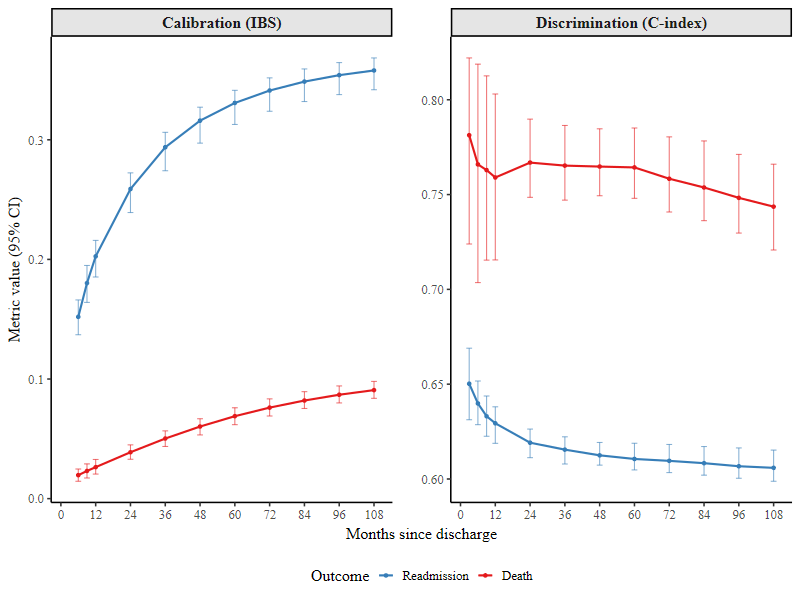

In [15]:
#| label: shap-criteria-dual-cox-plot-python-style-plot-by-time

tnr <- "Times New Roman"
set1_colors <- RColorBrewer::brewer.pal(n = 3, name = "Set1") # Set1 has up to 9 colors, but you only need 2
set1_colors <- rev(set1_colors[1:2])

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_py$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")


p_faceted <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted

In [16]:
#| label: shap-criteria-gvif

dplyr::bind_rows(
  rms::vif(survival::coxph(formula_shap_ds_death, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::arrange(dplyr::desc(dplyr::pick(2)[[1]])) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Death"),
  rms::vif(survival::coxph(formula_shap_ds_readmit, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Readmission")
) |>
  knitr::kable("markdown", caption = "GVIF for SHAP-based Cox models, using one imputed dataset")



Table: GVIF for SHAP-based Cox models, using one imputed dataset

|Variable                                   |     Gvif|Outcome     |
|:------------------------------------------|--------:|:-----------|
|evaluacindelprocesoteraputico_logro_minimo | 13.00597|Readmission |

In [17]:
formula_shap_ds_readmit_clean

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    sex_rec_woman + ethnicity + adm_age_rec3 + primary_sub_mod_cocaine_powder + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + tr_outcome_adm_discharge_rule_violation_undet + 
    polysubstance_strict + tr_outcome_dropout + primary_sub_mod_alcohol + 
    tr_outcome_referral + cohabitation_with_couple_children + 
    sub_dep_icd10_status_drug_dependence + eva_relinterp_logro_intermedio + 
    eva_relinterp_logro_minimo + porc_pobr + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_family_of_origin + 
    adm_motive_justice_sector + first_sub_used_alcohol + any_violence_1_domestic_violence_sex_abuse + 
    marital_status_rec

In [18]:
formula_shap_ds_death

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_alcohol + 
    occupation_condition_corr24_unemployed + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_with_couple_children + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    tr_outcome_adm_discharge_rule_violation_undet + occupation_condition_corr24_inactive + 
    adm_motive_sanitary_sector + polysubstance_strict + eva_sm_logro_intermedio + 
    eva_sm_logro_minimo + ed_attainment_corr_2_completed_high_school_or_less + 
    ed_attainment_corr_3_completed_primary_school_or_less + first_sub_used_alcohol + 
    primary_sub_mod_cocaine_paste + dg_psiq_cie_10_instudy + 
    strata(plan_type_strata)

In [19]:
#| label: shap-criteria2

options(future.globals.maxSize = 12 * 1024^3)

gc()

results_readmit_shap_ds_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_ds_readmit_clean,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
results_death_shap_ds_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_ds_death,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)

aicc_readmit_shap_ds <- compute_mi_aicc(formula_shap_ds_readmit_clean, py_corrected_datasets)#282719.30
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_shap_ds$mean_aic - aicc_readmit_upd2$mean_aic))
aicc_death_shap_ds <- compute_mi_aicc(formula_shap_ds_death, py_corrected_datasets)
#54321.99
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_death_shap_ds$mean_aic - aicc_death_upd2$mean_aic))
cat("Comparing readmission w/o collinear var and only one strata(plan)\n")
compare_mi_models_d1(formula_readmit_updated,formula_shap_ds_readmit_clean, py_corrected_datasets)

compare_mi_models_d1(formula_death_updated,formula_shap_ds_death, py_corrected_datasets)

Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3475 (95% CI: 0.3353 - 0.3604)
Valid bootstrap replicates: 500 / 500


Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  49 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  49 ; coefficient may be infinite. 


Strata variables: plan_type_strata
Categorical vars: plan_type_strata
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0887 (95% CI: 0.0822 - 0.0957)
Valid bootstrap replicates: 500 / 500

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  282667.66
Mean AICc: 282667.98
Correction added (Penalty): 0.322432
Parameters (k): 49 | Effective Sample Size (Events): 15247

Difference in Mean AIC: 10118.83

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  53924.67
Mean AICc: 53925.03
Correction added (Penalty): 0.366169
Parameters (k): 23 | Effective Sample Size (Events): 3039

Difference in Mean AIC: 2428.79
Comparing readmission w/o collinear var and only one strata(plan)
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom   p.value        riv
 1 ~~ 2  0.987814  15 5694.66

In [20]:
calibrate_cph_grouped_corr <- function(
    formula,
    data,
    times = c(12, 36, 60),
    n_imputations = NULL,
    validation = c("apparent", "cv"),
    folds = 5L,
    n_repeats = 10L,
    g = 10L,
    min_bin_n = 20L,
    compute_ici = FALSE,
    ici_times = NULL,
    ici_df = 4L,
    seed = 2125L,
    ties = "efron",
    verbose = TRUE,
    make_plots = FALSE,
    parallel_cv = TRUE,
    future_scheduling = 2,
    debug_fit = FALSE
) {
    if (!requireNamespace("survival", quietly = TRUE)) {
        stop("Package 'survival' is required.")
    }
    if (isTRUE(compute_ici) && !requireNamespace("splines", quietly = TRUE)) {
        stop("Package 'splines' is required when compute_ici = TRUE.")
    }
    if (isTRUE(make_plots) && !requireNamespace("ggplot2", quietly = TRUE)) {
        stop("Package 'ggplot2' is required when make_plots = TRUE.")
    }
    if (!inherits(formula, "formula")) stop("'formula' must be a formula.")

    validation <- match.arg(validation)

    if (!is.numeric(times) || length(times) == 0L || any(!is.finite(times)) || any(times < 0)) {
        stop("'times' must be a non-empty numeric vector of non-negative finite values.")
    }

    times <- sort(unique(as.numeric(times)))
    folds <- as.integer(folds)
    n_repeats <- as.integer(n_repeats)
    g <- as.integer(g)
    min_bin_n <- as.integer(min_bin_n)
    ici_df <- as.integer(ici_df)
    parallel_cv <- isTRUE(parallel_cv)

    if (is.null(ici_times)) {
        ici_times <- times
    } else {
        if (!is.numeric(ici_times) || any(!is.finite(ici_times))) {
            stop("'ici_times' must be numeric.")
        }
        ici_times <- sort(unique(as.numeric(ici_times)))
    }

    if (any(!ici_times %in% times)) stop("'ici_times' must be a subset of 'times'.")
    if (validation == "cv" && folds < 2L) stop("'folds' must be >= 2 when validation = 'cv'.")
    if (n_repeats < 1L) stop("'n_repeats' must be >= 1.")
    if (g < 1L) stop("'g' must be >= 1.")
    if (min_bin_n < 1L) stop("'min_bin_n' must be >= 1.")
    if (ici_df < 1L) stop("'ici_df' must be >= 1.")

    if (validation == "apparent" && n_repeats != 1L) {
        if (isTRUE(verbose)) {
            message("validation = 'apparent': using a single run and ignoring n_repeats > 1.")
        }
        n_repeats <- 1L
    }

    .msg <- function(...) {
        if (isTRUE(verbose)) message(...)
    }

    .run_stats <- function(x, probs = c(0.025, 0.975), type = 8) {
        x <- x[is.finite(x)]
        n <- length(x)
        if (n == 0L) {
            return(c(
                mean = NA_real_, sd = NA_real_, min = NA_real_,
                p025 = NA_real_, p975 = NA_real_, max = NA_real_, n = 0L
            ))
        }
        q <- stats::quantile(x, probs = c(0, probs, 1), na.rm = TRUE, names = FALSE, type = type)
        c(
            mean = mean(x),
            sd = if (n > 1L) stats::sd(x) else 0,
            min = q[1],
            p025 = q[2],
            p975 = q[3],
            max = q[4],
            n = n
        )
    }

    .qualify_survival_formula_helpers <- function(formula_obj) {
        f_txt <- paste(deparse(formula_obj, width.cutoff = 500L), collapse = " ")

        f_txt <- gsub(
            "(?<![:[:alnum:]_])Surv\\s*\\(",
            "survival::Surv(",
            f_txt,
            perl = TRUE
        )

        f_txt <- gsub(
            "(?<![:[:alnum:]_])strata\\s*\\(",
            "survival::strata(",
            f_txt,
            perl = TRUE
        )

        f_txt
    }

    .parse_surv_formula <- function(formula_obj) {
        surv_call <- formula_obj[[2]]

        if (!inherits(surv_call, "call")) {
            stop("Formula must have a Surv() response.")
        }

        surv_fun <- paste(deparse(surv_call[[1]]), collapse = "")

        if (!(surv_fun %in% c("Surv", "survival::Surv"))) {
            stop("Formula must have a Surv() response variable.")
        }

        if (length(surv_call) != 3L) {
            stop("This function supports only right-censored Surv(time, event) formulas.")
        }

        list(
            time_var  = as.character(surv_call[[2]]),
            event_var = as.character(surv_call[[3]])
        )
    }

    .rhs_formula <- function(formula_obj) {
        f_rhs <- stats::formula(stats::delete.response(stats::terms(formula_obj)))
        environment(f_rhs) <- environment(formula_obj)
        f_rhs
    }

    .as_df_list <- function(x, n_imputations = NULL) {
        if (is.data.frame(x)) {
            out <- list(as.data.frame(x))
        } else if (is.list(x) && length(x) > 0L && all(vapply(x, is.data.frame, logical(1)))) {
            out <- lapply(x, as.data.frame)
        } else {
            stop("'data' must be a data.frame or a list of data.frames.")
        }
        if (!is.null(n_imputations)) {
            out <- out[seq_len(min(as.integer(n_imputations), length(out)))]
        }
        out
    }

    .coerce_event01 <- function(x, varname) {
        if (is.logical(x)) return(as.integer(x))
        if (is.factor(x)) x <- as.character(x)

        if (is.character(x)) {
            out <- rep(NA_integer_, length(x))
            ok <- !is.na(x)
            x0 <- trimws(tolower(x[ok]))
            out_ok <- ifelse(
                x0 %in% c("1", "true", "yes", "y"), 1L,
                ifelse(x0 %in% c("0", "false", "no", "n"), 0L, NA_integer_)
            )
            bad_nonmissing <- is.na(out_ok)
            if (any(bad_nonmissing)) {
                bad_vals <- unique(x[ok][bad_nonmissing])
                stop(
                    "Variable '", varname,
                    "' contains non-missing values that cannot be coerced to 0/1: ",
                    paste(utils::head(bad_vals, 10), collapse = ", ")
                )
            }
            out[ok] <- out_ok
            return(out)
        }

        if (is.numeric(x) || is.integer(x)) {
            ux <- unique(stats::na.omit(x))
            if (!all(ux %in% c(0, 1))) {
                stop("Variable '", varname, "' must contain only 0/1 values (besides NA).")
            }
            return(as.integer(x))
        }

        stop("Variable '", varname, "' must be logical, numeric/integer 0/1, factor, or character.")
    }

    .prepare_survival_data <- function(d, time_var, event_var) {
        req <- c(time_var, event_var)
        miss <- setdiff(req, names(d))
        if (length(miss) > 0L) stop("Missing required columns: ", paste(miss, collapse = ", "))

        tt <- d[[time_var]]
        ee <- .coerce_event01(d[[event_var]], event_var)

        if (!is.numeric(tt)) stop("Time variable must be numeric.")
        if (any(tt < 0, na.rm = TRUE)) stop("Negative follow-up times are not allowed.")

        d$.ftime <- tt
        d$.status <- ee
        d
    }

    .analysis_mask <- function(d0, rhs_formula, time_var, event_var) {
        mf_rhs <- stats::model.frame(rhs_formula, data = d0, na.action = stats::na.pass)
        stats::complete.cases(d0[, c(time_var, event_var, ".ftime", ".status"), drop = FALSE]) &
            stats::complete.cases(mf_rhs)
    }

    .validate_analysis_data <- function(dcc, validation, folds) {
        n <- nrow(dcc)
        n_events <- sum(dcc$.status == 1L, na.rm = TRUE)

        if (n == 0L) stop("No complete cases remain after unified filtering.")
        if (n_events < 1L) stop("No events remain in the analysis cohort.")

        if (validation == "cv") {
            if (folds > n) stop("'folds' cannot exceed the analysis sample size.")
            if (n_events < 2L) stop("Cross-validation is not feasible: fewer than 2 events remain.")
        }

        invisible(TRUE)
    }

    .make_stratified_folds <- function(status, folds, seed_local) {
        set.seed(seed_local)
        n <- length(status)
        if (folds > n) stop("'folds' cannot exceed sample size.")

        fold_id <- integer(n)
        classes <- sort(unique(status))
        offset <- 0L

        for (cl in classes) {
            idx <- which(status == cl)
            idx <- sample(idx, length(idx), replace = FALSE)
            assign <- ((seq_along(idx) - 1L + offset) %% folds) + 1L
            fold_id[idx] <- assign
            offset <- (offset + length(idx)) %% folds
        }

        tab <- tabulate(fold_id, nbins = folds)
        while (any(tab == 0L)) {
            empty_fold <- which(tab == 0L)[1L]
            donor_fold <- which.max(tab)
            donor_idx <- which(fold_id == donor_fold)
            move_idx <- sample(donor_idx, 1L)
            fold_id[move_idx] <- empty_fold
            tab <- tabulate(fold_id, nbins = folds)
        }

        for (k in seq_len(folds)) {
            tr_status <- status[fold_id != k]
            if (sum(tr_status == 1L, na.rm = TRUE) == 0L) {
                stop("Invalid fold split: training fold ", k, " has zero events.")
            }
            if (sum(fold_id == k) == 0L) {
                stop("Invalid fold split: test fold ", k, " is empty.")
            }
        }

        fold_id
    }
    .fit_cox_and_predict_many <- function(
        train_data,
        test_data,
        formula,
        time_var,
        times,
        ties = "efron",
        vars_needed = NULL,
        debug = FALSE
    ) {
        if (is.null(vars_needed)) vars_needed <- unique(all.vars(formula))

        train_data <- train_data[, vars_needed, drop = FALSE]
        test_data  <- test_data[, vars_needed, drop = FALSE]

        if (debug) {
            mf <- stats::model.frame(formula, data = train_data, na.action = stats::na.pass)
            X  <- stats::model.matrix(formula, data = mf)

            inf_cols <- colnames(X)[apply(X, 2, function(z) any(is.infinite(z)))]
            nan_cols <- colnames(X)[apply(X, 2, function(z) any(is.nan(z)))]
            na_cols  <- colnames(X)[apply(X, 2, function(z) any(is.na(z)))]
            const_cols <- apply(X, 2, function(z) length(unique(z[is.finite(z)])) <= 1)
            const_names <- setdiff(colnames(X)[const_cols], "(Intercept)")

            if (length(inf_cols) > 0) message("Inf columns: ", paste(inf_cols, collapse = ", "))
            if (length(nan_cols) > 0) message("NaN columns: ", paste(nan_cols, collapse = ", "))
            if (length(na_cols) > 0)  message("NA columns in model matrix: ", paste(na_cols, collapse = ", "))
            if (length(const_names) > 0) {
                message("Constant non-intercept columns detected: ", paste(const_names, collapse = ", "))
            }
        }

        fit <- survival::coxph(
            formula = formula,
            data = train_data,
            ties = ties,
            x = TRUE,
            y = TRUE,
            model = TRUE
        )

        pred <- sapply(times, function(tt) {
            dtemp <- test_data
            dtemp[[time_var]] <- tt
            cumhaz <- stats::predict(fit, newdata = dtemp, type = "expected")
            risk <- 1 - exp(-cumhaz)
            risk[!is.finite(risk)] <- NA_real_
            pmin(pmax(risk, 0), 1)
        })

        if (is.vector(pred)) pred <- matrix(pred, ncol = 1L)
        colnames(pred) <- paste0("t_", times)
        pred
    }

    .run_one_fold <- function(
        task,
        analysis_data,
        times,
        M,
        formula,
        time_var,
        ties,
        vars_needed,
        debug_fit,
        .fit_fn
    ) {
        tr_idx <- task$tr_idx
        te_idx <- task$te_idx
        pred_sum <- matrix(0, nrow = length(te_idx), ncol = length(times))

        for (m in seq_len(M)) {
            pred_m <- tryCatch(
                .fit_fn(
                    train_data = analysis_data[[m]][tr_idx, , drop = FALSE],
                    test_data  = analysis_data[[m]][te_idx, , drop = FALSE],
                    formula = formula,
                    time_var = time_var,
                    times = times,
                    ties = ties,
                    vars_needed = vars_needed,
                    debug = debug_fit
                ),
                error = function(e) {
                    stop(
                        "Parallel task failed at repetition=", task$r,
                        ", fold=", task$k,
                        ", imputation=", m,
                        ": ", conditionMessage(e),
                        call. = FALSE
                    )
                }
            )
            pred_sum <- pred_sum + pred_m
        }

        list(
            r = task$r,
            te_idx = te_idx,
            pred_fold_avg = pred_sum / M
        )
    }


    .make_cutpoints <- function(x, g = 10L) {
        x <- x[is.finite(x)]
        if (length(x) == 0L) return(numeric(0))
        if (length(unique(x)) == 1L) return(numeric(0))
        probs <- seq(0, 1, length.out = g + 1L)
        q <- stats::quantile(x, probs = probs, na.rm = TRUE, names = FALSE, type = 8)
        unique(q[-c(1, length(q))])
    }

    .assign_bins <- function(x, cutpoints) {
        bins <- rep(NA_integer_, length(x))
        ok <- is.finite(x)
        if (!any(ok)) return(bins)
        if (length(cutpoints) == 0L) {
            bins[ok] <- 1L
        } else {
            bins[ok] <- findInterval(x[ok], vec = cutpoints, all.inside = TRUE) + 1L
        }
        bins
    }

    .build_global_bin_map <- function(x, cutpoints, min_bin_n) {
        bins0 <- .assign_bins(x, cutpoints)
        levs <- sort(unique(stats::na.omit(bins0)))
        if (length(levs) == 0L) return(integer(0))

        groups <- lapply(levs, function(z) z)
        counts_full <- tabulate(bins0[!is.na(bins0)], nbins = max(levs))
        counts <- as.numeric(counts_full[levs])

        repeat {
            n_groups <- length(groups)
            if (n_groups == 1L) break

            small <- which(counts < min_bin_n)
            if (length(small) == 0L) break

            g_idx <- small[1L]
            if (g_idx == 1L) {
                target <- 2L
            } else if (g_idx == n_groups) {
                target <- n_groups - 1L
            } else {
                target <- if (counts[g_idx - 1L] <= counts[g_idx + 1L]) g_idx - 1L else g_idx + 1L
            }

            groups[[target]] <- sort(c(groups[[target]], groups[[g_idx]]))
            counts[target] <- counts[target] + counts[g_idx]

            keep <- setdiff(seq_len(n_groups), g_idx)
            groups <- groups[keep]
            counts <- counts[keep]
        }

        n_orig_bins <- if (length(cutpoints) == 0L) 1L else length(cutpoints) + 1L
        bin_map <- rep(NA_integer_, n_orig_bins)

        if (length(groups) == 1L && counts[1L] < min_bin_n) return(bin_map)

        for (i in seq_along(groups)) {
            bin_map[unlist(groups[[i]], use.names = FALSE)] <- i
        }

        bin_map
    }

    .apply_bin_map <- function(bins, bin_map) {
        out <- rep(NA_integer_, length(bins))
        ok <- !is.na(bins) & bins >= 1L & bins <= length(bin_map)
        if (any(ok)) out[ok] <- bin_map[bins[ok]]
        out
    }

    .km_risk_at_time <- function(time, event, t_horizon) {
        fit <- survival::survfit(survival::Surv(time, event) ~ 1)
        s <- summary(fit, times = t_horizon, extend = TRUE)

        if (length(s$surv) == 0L || is.na(s$surv[1])) {
            return(list(risk = NA_real_, lower = NA_real_, upper = NA_real_))
        }

        surv_t <- as.numeric(s$surv[1])
        lower_s <- if (!is.null(s$lower) && length(s$lower) > 0L) as.numeric(s$lower[1]) else surv_t
        upper_s <- if (!is.null(s$upper) && length(s$upper) > 0L) as.numeric(s$upper[1]) else surv_t

        list(
            risk = 1 - surv_t,
            lower = 1 - upper_s,
            upper = 1 - lower_s
        )
    }

    .grouped_calibration <- function(d, pred_vec, t_horizon, cutpoints, bin_map, min_bin_n) {
        bins0 <- .assign_bins(pred_vec, cutpoints)
        bins <- .apply_bin_map(bins0, bin_map)
        levs <- sort(unique(stats::na.omit(bins)))

        if (length(levs) == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        out <- vector("list", length(levs))
        keep_idx <- 0L

        for (b in levs) {
            idx <- which(bins == b)
            if (length(idx) < min_bin_n) next

            km <- .km_risk_at_time(
                time = d$.ftime[idx],
                event = d$.status[idx],
                t_horizon = t_horizon
            )

            keep_idx <- keep_idx + 1L
            out[[keep_idx]] <- data.frame(
                bin = b,
                mean_predicted = mean(pred_vec[idx], na.rm = TRUE),
                observed = km$risk,
                observed_lower = km$lower,
                observed_upper = km$upper,
                n_patients = length(idx),
                stringsAsFactors = FALSE
            )
        }

        if (keep_idx == 0L) {
            return(list(curve = NULL, n_used = 0L, n_excluded = sum(is.finite(pred_vec))))
        }

        curve <- do.call(rbind, out[seq_len(keep_idx)])
        list(
            curve = curve,
            n_used = sum(curve$n_patients),
            n_excluded = sum(is.finite(pred_vec)) - sum(curve$n_patients)
        )
    }
    .smooth_calibration_metrics_surv <- function(d, pred_vec, t_horizon, ici_df = 4L, eps = 1e-06) {
        pred_use <- pmin(pmax(pred_vec, eps), 1 - eps)
        z <- log(-log(1 - pred_use))

        if (any(!is.finite(z))) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        fit_once <- function(df_use) {
            d_fit <- d
            d_fit$.cll_pred <- z

            if (df_use <= 1L || length(unique(z)) <= 3L) {
                f_cal <- survival::Surv(.ftime, .status) ~ .cll_pred
            } else {
                df_eff <- min(as.integer(df_use), length(unique(z)) - 1L)
                basis <- as.data.frame(splines::ns(z, df = df_eff))
                names(basis) <- paste0("ici_s", seq_len(ncol(basis)))
                d_fit[names(basis)] <- basis
                rhs <- paste(names(basis), collapse = " + ")
                f_cal <- stats::as.formula(paste0("survival::Surv(.ftime, .status) ~ ", rhs))
            }

            fit <- survival::coxph(
                formula = f_cal,
                data = d_fit,
                ties = ties,
                x = FALSE,
                y = FALSE,
                model = TRUE
            )

            lp <- stats::predict(fit, newdata = d_fit, type = "lp")
            bh <- survival::basehaz(fit, centered = FALSE)
            H0_t <- stats::approx(
                x = bh$time,
                y = bh$hazard,
                xout = t_horizon,
                method = "constant",
                rule = 2,
                f = 0
            )$y
            risk_t <- 1 - exp(-H0_t * exp(lp))
            list(risk_t = risk_t)
        }

        fit_obj <- tryCatch(
            fit_once(ici_df),
            error = function(e1) {
                tryCatch(
                    fit_once(1L),
                    error = function(e2) {
                        warning("Survival ICI smoother failed at time ", t_horizon, ": ", conditionMessage(e1), call. = FALSE)
                        NULL
                    }
                )
            }
        )

        if (is.null(fit_obj)) {
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        obs_smooth <- fit_obj$risk_t

        if (length(obs_smooth) != length(pred_vec) || any(!is.finite(obs_smooth))) {
            warning("Survival ICI prediction failed at time ", t_horizon, ".", call. = FALSE)
            return(list(
                ici = NA_real_,
                e50 = NA_real_,
                e90 = NA_real_,
                emax = NA_real_,
                smoothed_observed = rep(NA_real_, length(pred_vec))
            ))
        }

        abs_err <- abs(obs_smooth - pred_vec)

        list(
            ici = mean(abs_err, na.rm = TRUE),
            e50 = as.numeric(stats::quantile(abs_err, probs = 0.50, na.rm = TRUE, names = FALSE, type = 8)),
            e90 = as.numeric(stats::quantile(abs_err, probs = 0.90, na.rm = TRUE, names = FALSE, type = 8)),
            emax = max(abs_err, na.rm = TRUE),
            smoothed_observed = obs_smooth
        )
    }

    .pool_summary <- function(by_repetition) {
        if (nrow(by_repetition) == 0L) return(by_repetition)

        time_levels <- sort(unique(by_repetition$time_months))
        out <- lapply(time_levels, function(tt) {
            z <- by_repetition[by_repetition$time_months == tt, , drop = FALSE]

            ici_st <- .run_stats(z$ici)
            e50_st <- .run_stats(z$e50)
            e90_st <- .run_stats(z$e90)
            emax_st <- .run_stats(z$emax)
            ece_st <- .run_stats(z$ece)
            eo_st <- .run_stats(z$eo_ratio)
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)

            data.frame(
                time_months = tt,
                ici_mean = unname(ici_st["mean"]),
                ici_sd = unname(ici_st["sd"]),
                ici_min = unname(ici_st["min"]),
                ici_p025 = unname(ici_st["p025"]),
                ici_p975 = unname(ici_st["p975"]),
                ici_max = unname(ici_st["max"]),
                e50_mean = unname(e50_st["mean"]),
                e50_sd = unname(e50_st["sd"]),
                e50_min = unname(e50_st["min"]),
                e50_p025 = unname(e50_st["p025"]),
                e50_p975 = unname(e50_st["p975"]),
                e50_max = unname(e50_st["max"]),
                e90_mean = unname(e90_st["mean"]),
                e90_sd = unname(e90_st["sd"]),
                e90_min = unname(e90_st["min"]),
                e90_p025 = unname(e90_st["p025"]),
                e90_p975 = unname(e90_st["p975"]),
                e90_max = unname(e90_st["max"]),
                emax_mean = unname(emax_st["mean"]),
                emax_sd = unname(emax_st["sd"]),
                emax_min = unname(emax_st["min"]),
                emax_p025 = unname(emax_st["p025"]),
                emax_p975 = unname(emax_st["p975"]),
                emax_max = unname(emax_st["max"]),
                ece_mean = unname(ece_st["mean"]),
                ece_sd = unname(ece_st["sd"]),
                ece_min = unname(ece_st["min"]),
                ece_p025 = unname(ece_st["p025"]),
                ece_p975 = unname(ece_st["p975"]),
                ece_max = unname(ece_st["max"]),
                eo_mean = unname(eo_st["mean"]),
                eo_sd = unname(eo_st["sd"]),
                eo_min = unname(eo_st["min"]),
                eo_p025 = unname(eo_st["p025"]),
                eo_p975 = unname(eo_st["p975"]),
                eo_max = unname(eo_st["max"]),
                mean_pred = unname(mp_st["mean"]),
                mean_pred_sd = unname(mp_st["sd"]),
                mean_pred_min = unname(mp_st["min"]),
                mean_pred_p025 = unname(mp_st["p025"]),
                mean_pred_p975 = unname(mp_st["p975"]),
                mean_pred_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months), , drop = FALSE]
    }

    .pool_curves <- function(curves_df) {
        if (nrow(curves_df) == 0L) return(curves_df)

        key <- paste(curves_df$time_months, curves_df$bin, sep = "___")
        spl <- split(curves_df, key)

        out <- lapply(spl, function(z) {
            mp_st <- .run_stats(z$mean_predicted)
            obs_st <- .run_stats(z$observed)
            low_st <- .run_stats(z$observed_lower)
            upp_st <- .run_stats(z$observed_upper)

            data.frame(
                time_months = unique(z$time_months),
                bin = unique(z$bin),
                mean_predicted = unname(mp_st["mean"]),
                mean_predicted_sd = unname(mp_st["sd"]),
                mean_predicted_min = unname(mp_st["min"]),
                mean_predicted_p025 = unname(mp_st["p025"]),
                mean_predicted_p975 = unname(mp_st["p975"]),
                mean_predicted_max = unname(mp_st["max"]),
                observed = unname(obs_st["mean"]),
                observed_sd = unname(obs_st["sd"]),
                observed_min = unname(obs_st["min"]),
                observed_p025 = unname(obs_st["p025"]),
                observed_p975 = unname(obs_st["p975"]),
                observed_max = unname(obs_st["max"]),
                observed_lower = unname(low_st["mean"]),
                observed_upper = unname(upp_st["mean"]),
                n_total = sum(z$n_patients, na.rm = TRUE),
                n_runs = nrow(z),
                n_imp = M,
                stringsAsFactors = FALSE
            )
        })

        out <- do.call(rbind, out)
        rownames(out) <- NULL
        out[order(out$time_months, out$bin), , drop = FALSE]
    }

    formula_txt <- .qualify_survival_formula_helpers(formula)
    formula_eval <- stats::as.formula(formula_txt, env = environment(formula))

    surv_info <- .parse_surv_formula(formula_eval)
    time_var <- surv_info$time_var
    event_var <- surv_info$event_var
    rhs_formula <- .rhs_formula(formula_eval)
    vars_needed <- unique(all.vars(formula_eval))

    data_list <- .as_df_list(data, n_imputations = n_imputations)
    M <- length(data_list)
    effective_repeats <- if (validation == "cv") n_repeats else 1L

    .msg("Detected time variable: ", time_var)
    .msg("Detected event variable: ", event_var)
    .msg("Using ", M, " imputed dataset(s).")
    .msg("Validation: ", validation)
    if (validation == "cv") {
        .msg("Repetitions: ", effective_repeats, " | same fold split across imputations within each repetition.")
    }
    if (isTRUE(compute_ici)) {
        .msg("ICI: enabled at horizons ", paste(ici_times, collapse = ", "), ".")
    } else {
        .msg("ICI: disabled.")
    }

    d0_list <- lapply(data_list, function(dd) {
        .prepare_survival_data(as.data.frame(dd), time_var, event_var)
    })

    if (M > 1L) {
        ref0 <- d0_list[[1L]]
        for (m in 2:M) {
            if (nrow(d0_list[[m]]) != nrow(ref0)) {
                stop("All imputations must have the same number of rows and row order.")
            }
            same_time <- isTRUE(all.equal(ref0$.ftime, d0_list[[m]]$.ftime, tolerance = 1e-08, check.attributes = FALSE))
            same_status <- identical(ref0$.status, d0_list[[m]]$.status)
            if (!same_time || !same_status) {
                stop("Outcome/time information differs across imputations. This workflow assumes only predictors were imputed.")
            }
        }
    }

    mask_list <- lapply(d0_list, function(d0) .analysis_mask(d0, rhs_formula, time_var, event_var))
    keep_all <- Reduce(`&`, mask_list)

    n_input <- nrow(d0_list[[1L]])
    n_analysis <- sum(keep_all)
    n_dropped <- n_input - n_analysis

    if (n_dropped > 0L) {
        .msg("Dropping ", n_dropped, " rows due to missing outcomes/times/model covariates in at least one imputation.")
    }

    analysis_data <- lapply(d0_list, function(d0) {
        out <- d0[keep_all, , drop = FALSE]
        rownames(out) <- NULL
        out
    })

    reference_data <- analysis_data[[1L]]
    .validate_analysis_data(reference_data, validation, folds)

    n_events_total <- sum(reference_data$.status == 1L, na.rm = TRUE)

    reference_observed <- do.call(rbind, lapply(times, function(tt) {
        km <- .km_risk_at_time(reference_data$.ftime, reference_data$.status, tt)
        data.frame(
            time_months = tt,
            observed = km$risk,
            observed_lower = km$lower,
            observed_upper = km$upper,
            stringsAsFactors = FALSE
        )
    }))

    pred_rep_list <- list()

    if (validation == "apparent") {
        .msg("Fitting apparent predictions averaged across imputations...", appendLF = FALSE)

        pred_sum <- matrix(0, nrow = n_analysis, ncol = length(times))
        for (m in seq_len(M)) {
            pred_m <- .fit_cox_and_predict_many(
                train_data = analysis_data[[m]],
                test_data = analysis_data[[m]],
                formula_txt = formula_txt,
                time_var = time_var,
                times = times,
                ties = ties,
                vars_needed = vars_needed,
                debug = debug_fit
            )
            pred_sum <- pred_sum + pred_m
        }

        pred_avg <- pred_sum / M
        colnames(pred_avg) <- paste0("t_", times)
        pred_rep_list[[1L]] <- list(repetition = 1L, pred = pred_avg)

        .msg(" done")
    } else {
        task_list <- unlist(
            lapply(seq_len(effective_repeats), function(r) {
                fold_id <- .make_stratified_folds(
                    reference_data$.status,
                    folds = folds,
                    seed_local = seed + r
                )
                lapply(seq_len(folds), function(k) {
                    list(
                        r = r,
                        k = k,
                        tr_idx = which(fold_id != k),
                        te_idx = which(fold_id == k)
                    )
                })
            }),
            recursive = FALSE
        )

        if (parallel_cv) {
            if (!requireNamespace("future.apply", quietly = TRUE)) {
                stop("Package 'future.apply' is required when parallel_cv = TRUE.")
            }

            .msg(
                "Running CV predictions in parallel across ",
                length(task_list),
                " repetition x fold tasks...",
                appendLF = FALSE
            )

            task_results <- future.apply::future_lapply(
                X = task_list,
                FUN = .run_one_fold,
                analysis_data = analysis_data,
                times = times,
                M = M,
                formula = formula_eval,
                time_var = time_var,
                ties = ties,
                vars_needed = vars_needed,
                debug_fit = debug_fit,
                .fit_fn = .fit_cox_and_predict_many,
                future.seed = TRUE,
                future.globals = FALSE,
                future.packages = c("survival", "splines"),
                future.scheduling = future_scheduling
            )
            .msg(" done")
        } else {
            .msg(
                "Running CV predictions sequentially across ",
                length(task_list),
                " repetition x fold tasks...",
                appendLF = FALSE
            )

            task_results <- lapply(
                X = task_list,
                FUN = .run_one_fold,
                analysis_data = analysis_data,
                times = times,
                M = M,
                formula = formula_eval,
                time_var = time_var,
                ties = ties,
                vars_needed = vars_needed,
                debug_fit = debug_fit,
                .fit_fn = .fit_cox_and_predict_many
            )

            .msg(" done")
        }

        for (r in seq_len(effective_repeats)) {
            pred_avg <- matrix(NA_real_, nrow = n_analysis, ncol = length(times))
            r_hits <- task_results[vapply(task_results, function(x) x$r, integer(1L)) == r]

            for (res in r_hits) {
                pred_avg[res$te_idx, ] <- res$pred_fold_avg
            }

            if (any(!is.finite(pred_avg))) {
                stop("Non-finite predictions remained after averaging across imputations in repetition ", r, ".")
            }

            colnames(pred_avg) <- paste0("t_", times)
            pred_rep_list[[length(pred_rep_list) + 1L]] <- list(repetition = r, pred = pred_avg)
        }
    }

    common_cutpoints <- vector("list", length(times))
    common_bin_maps <- vector("list", length(times))
    names(common_cutpoints) <- paste0("t_", times)
    names(common_bin_maps) <- paste0("t_", times)

    for (j in seq_along(times)) {
        pooled_preds_j <- unlist(lapply(pred_rep_list, function(obj) obj$pred[, j]), use.names = FALSE)
        cuts_j <- .make_cutpoints(pooled_preds_j, g = g)
        common_cutpoints[[j]] <- cuts_j
        common_bin_maps[[j]] <- .build_global_bin_map(
            x = pooled_preds_j,
            cutpoints = cuts_j,
            min_bin_n = min_bin_n
        )
    }

    curves_all <- list()
    metrics_all <- list()

    for (rep_idx in seq_along(pred_rep_list)) {
        rep_obj <- pred_rep_list[[rep_idx]]
        r <- rep_obj$repetition
        pred_r <- rep_obj$pred

        .msg("Calibrating repetition ", r, "/", length(pred_rep_list), "...", appendLF = FALSE)

        for (j in seq_along(times)) {
            t_horizon <- times[j]
            pred_vec <- pred_r[, j]

            calib_obj <- .grouped_calibration(
                d = reference_data,
                pred_vec = pred_vec,
                t_horizon = t_horizon,
                cutpoints = common_cutpoints[[j]],
                bin_map = common_bin_maps[[j]],
                min_bin_n = min_bin_n
            )

            calib_df <- calib_obj$curve

            if (is.null(calib_df) || nrow(calib_df) == 0L) {
                warning("No calibration bins survived for repetition ", r, " at time ", t_horizon, ".", call. = FALSE)
                next
            }

            obs_row <- reference_observed[reference_observed$time_months == t_horizon, , drop = FALSE]
            ece <- stats::weighted.mean(
                abs(calib_df$mean_predicted - calib_df$observed),
                w = calib_df$n_patients,
                na.rm = TRUE
            )

            if (isTRUE(compute_ici) && t_horizon %in% ici_times) {
                ici_obj <- .smooth_calibration_metrics_surv(
                    d = reference_data,
                    pred_vec = pred_vec,
                    t_horizon = t_horizon,
                    ici_df = ici_df
                )
            } else {
                ici_obj <- list(
                    ici = NA_real_,
                    e50 = NA_real_,
                    e90 = NA_real_,
                    emax = NA_real_
                )
            }

            mean_pred <- mean(pred_vec, na.rm = TRUE)
            eo_ratio <- if (is.na(obs_row$observed[1]) || obs_row$observed[1] <= 0) {
                NA_real_
            } else {
                mean_pred / obs_row$observed[1]
            }
            n_events <- sum(reference_data$.ftime <= t_horizon & reference_data$.status == 1L, na.rm = TRUE)

            calib_df$repetition <- r
            calib_df$time_months <- t_horizon
            curves_all[[length(curves_all) + 1L]] <- calib_df

            metrics_all[[length(metrics_all) + 1L]] <- data.frame(
                repetition = r,
                time_months = t_horizon,
                ici = ici_obj$ici,
                e50 = ici_obj$e50,
                e90 = ici_obj$e90,
                emax = ici_obj$emax,
                ece = ece,
                eo_ratio = eo_ratio,
                mean_predicted = mean_pred,
                observed = obs_row$observed[1],
                observed_lower = obs_row$observed_lower[1],
                observed_upper = obs_row$observed_upper[1],
                n_input = n_input,
                n_analysis = n_analysis,
                n_dropped = n_dropped,
                n_events = n_events,
                n_events_total = n_events_total,
                n_used_calibration = calib_obj$n_used,
                n_excluded_calibration = calib_obj$n_excluded,
                n_bins = nrow(calib_df),
                n_imputations = M,
                stringsAsFactors = FALSE
            )
        }

        .msg(" done")
    }

    by_repetition <- if (length(metrics_all) > 0L) do.call(rbind, metrics_all) else data.frame()
    curves_df <- if (length(curves_all) > 0L) do.call(rbind, curves_all) else data.frame()

    if (isTRUE(compute_ici) && nrow(by_repetition) > 0L) {
        ici_rows <- by_repetition$time_months %in% ici_times
        if (any(ici_rows) && all(is.na(by_repetition$ici[ici_rows]))) {
            warning("ICI/E50/E90/Emax could not be computed for the requested ICI horizons.", call. = FALSE)
        }
    }

    pooled_summary <- if (nrow(by_repetition) > 0L) .pool_summary(by_repetition) else data.frame()
    pooled_curves <- if (nrow(curves_df) > 0L) .pool_curves(curves_df) else data.frame()

    plot_list <- list()
    combined_plot <- NULL

    if (isTRUE(make_plots) && nrow(pooled_curves) > 0L) {
        event_label <- gsub("_", " ", event_var)

        for (tt in times) {
            pdat <- pooled_curves[pooled_curves$time_months == tt, , drop = FALSE]
            rdat <- curves_df[curves_df$time_months == tt, , drop = FALSE]
            if (nrow(pdat) == 0L) next

            lim_max <- max(
                c(rdat$mean_predicted, rdat$observed, pdat$mean_predicted_p975, pdat$observed_p975),
                na.rm = TRUE
            )
            lim_max <- max(0.05, lim_max * 1.05)

            srow <- pooled_summary[pooled_summary$time_months == tt, , drop = FALSE]
            subtxt <- if (nrow(srow) == 1L) {
                paste0(
                    "Validation: ", validation,
                    if (validation == "cv") paste0(" | repetitions = ", effective_repeats) else "",
                    if (M > 1L) paste0(" | imputations averaged = ", M) else "",
                    if (isTRUE(compute_ici) && tt %in% ici_times) {
                        paste0(
                            " | ICI mean = ", formatC(srow$ici_mean, digits = 4, format = "f"),
                            " | SD = ", formatC(srow$ici_sd, digits = 4, format = "f")
                        )
                    } else {
                        " | ICI not computed"
                    },
                    " | E/O mean = ", formatC(srow$eo_mean, digits = 4, format = "f"),
                    " | SD = ", formatC(srow$eo_sd, digits = 4, format = "f")
                )
            } else {
                paste0("Validation: ", validation)
            }

            p <- ggplot2::ggplot() +
                ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
                ggplot2::geom_line(
                    data = rdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = repetition),
                    color = "gray70",
                    alpha = 0.55,
                    linewidth = 0.4
                ) +
                ggplot2::geom_ribbon(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = 1),
                    fill = "gray70",
                    alpha = 0.25
                ) +
                ggplot2::geom_line(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed, group = 1),
                    color = "steelblue",
                    linewidth = 0.9
                ) +
                ggplot2::geom_point(
                    data = pdat,
                    ggplot2::aes(x = mean_predicted, y = observed),
                    size = 2.5,
                    shape = 21,
                    fill = "white",
                    color = "steelblue"
                ) +
                ggplot2::coord_equal(xlim = c(0, lim_max), ylim = c(0, lim_max)) +
                ggplot2::labs(
                    title = paste0(tt, " months"),
                    subtitle = subtxt,
                    x = paste0("Predicted probability of ", event_label),
                    y = paste0("Observed KM risk of ", event_label)
                ) +
                ggplot2::theme_minimal()

            plot_list[[paste0("month_", tt)]] <- p
        }

        combined_plot <- ggplot2::ggplot() +
            ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
            ggplot2::geom_line(
                data = curves_df,
                ggplot2::aes(x = mean_predicted, y = observed, group = interaction(time_months, repetition)),
                color = "gray70",
                alpha = 0.5,
                linewidth = 0.35
            ) +
            ggplot2::geom_ribbon(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, ymin = observed_p025, ymax = observed_p975, group = time_months),
                fill = "gray70",
                alpha = 0.25
            ) +
            ggplot2::geom_line(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed, group = time_months),
                color = "steelblue",
                linewidth = 0.85
            ) +
            ggplot2::geom_point(
                data = pooled_curves,
                ggplot2::aes(x = mean_predicted, y = observed),
                size = 1.8,
                color = "steelblue"
            ) +
            ggplot2::facet_wrap(~time_months, scales = "free") +
            ggplot2::labs(
                title = paste0("Grouped calibration of Cox predictions for ", event_label),
                subtitle = paste0(
                    "Gray lines = repetitions | Gray ribbon = pointwise 2.5th-97.5th percentile across repetitions | Blue = mean",
                    if (validation == "cv") paste0(" | repeated ", folds, "-fold CV x ", effective_repeats) else ""
                ),
                x = paste0("Predicted probability of ", event_label),
                y = paste0("Observed KM risk of ", event_label)
            ) +
            ggplot2::theme_minimal()
    }

    structure(
        list(
            by_repetition = by_repetition,
            by_run = by_repetition,
            pooled_summary = pooled_summary,
            calibration_curves = pooled_curves,
            raw_curves = curves_df,
            reference_observed = reference_observed,
            plots = plot_list,
            combined_plot = combined_plot,
            cutpoints = common_cutpoints,
            bin_maps = common_bin_maps,
            variable_names = list(time = time_var, event = event_var),
            settings = list(
                times = times,
                n_imputations = M,
                validation = validation,
                folds = if (validation == "cv") folds else NA_integer_,
                n_repeats = effective_repeats,
                n_runs_total = effective_repeats,
                g = g,
                min_bin_n = min_bin_n,
                compute_ici = isTRUE(compute_ici),
                ici_times = ici_times,
                ici_df = ici_df,
                ties = ties,
                parallel_cv = parallel_cv,
                future_scheduling = future_scheduling,
                debug_fit = debug_fit,
                workflow = "parallel by repetition x fold; average held-out predictions across imputations; variability across repetitions"
            )
        ),
        class = "cph_grouped_calibration_corr"
    )
}

print.cph_grouped_calibration_corr <- function(x, ...) {
    cat("<cph_grouped_calibration_corr>\n\n")
    cat("$pooled_summary\n")
    print.data.frame(x$pooled_summary, row.names = FALSE)
    invisible(x)
}

In [21]:
#| label: shap-criteria3

future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)

cal_readmit_shap_ds <- calibrate_cph_grouped_corr(
  formula = formula_shap_ds_readmit_clean,
  data = py_corrected_datasets,
  times = c(12, 36, 60, 96),
  seed = 2125,
  validation = "cv",
  n_repeats = 20,
  n_imputations = 5,
  compute_ici = TRUE,
  ici_times = 60,
  make_plots = TRUE,
  parallel_cv = T,
  future_scheduling = 2,
  debug_fit = T
)
print.cph_grouped_calibration_corr(cal_readmit_shap_ds)

cal_death_shap_ds <- calibrate_cph_grouped_corr(
  formula = formula_shap_ds_death,
  data = py_corrected_datasets,
  times = c(12, 36, 60, 96),
  seed = 2125,
  validation = "cv",
  n_repeats = 20,
  n_imputations = 5,
  compute_ici = TRUE,
  ici_times = 60,
  make_plots = TRUE,
  parallel_cv = T,
  future_scheduling = 2,
  debug_fit = FALSE
)
print.cph_grouped_calibration_corr(cal_death_shap_ds)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2

In [22]:
#| label: shap-criteria-nph-readm

cox.zph(coxph(formula_shap_ds_readmit_clean, data= py_corrected_datasets[[1]]))

                                                              chisq df       p
primary_sub_mod_cocaine_paste                               0.09180  1 0.76191
sex_rec_woman                                               1.15110  1 0.28332
ethnicity                                                   4.34187  1 0.03719
adm_age_rec3                                                5.49694  1 0.01905
primary_sub_mod_cocaine_powder                              0.06733  1 0.79527
eva_consumo_logro_intermedio                                1.50628  1 0.21971
eva_consumo_logro_minimo                                    6.03252  1 0.01404
ed_attainment_corr_2_completed_high_school_or_less          7.93740  1 0.00484
ed_attainment_corr_3_completed_primary_school_or_less      11.67897  1 0.00063
dg_psiq_cie_10_dg                                           0.36015  1 0.54842
eva_sm_logro_intermedio                                     2.08355  1 0.14889
eva_sm_logro_minimo                                 

In [23]:
#| label: shap-criteria-nph2-death

cox.zph(coxph(formula_shap_ds_death, data= py_corrected_datasets[[1]]))

                                                          chisq df        p
adm_age_rec3                                            0.00605  1   0.9380
primary_sub_mod_alcohol                                 0.32443  1   0.5690
occupation_condition_corr24_unemployed                  1.65660  1   0.1981
any_phys_dx                                            15.26051  1 0.000094
prim_sub_freq_rec_2_2_6_days_wk                         0.93913  1   0.3325
prim_sub_freq_rec_3_daily                               1.65413  1   0.1984
cohabitation_with_couple_children                       4.17642  1   0.0410
eva_ocupacion_logro_intermedio                          0.36324  1   0.5467
eva_ocupacion_logro_minimo                              3.74953  1   0.0528
eva_fisica_logro_intermedio                             2.16153  1   0.1415
eva_fisica_logro_minimo                                10.62730  1   0.0011
sex_rec_woman                                           0.37405  1   0.5408
tr_outcome_a

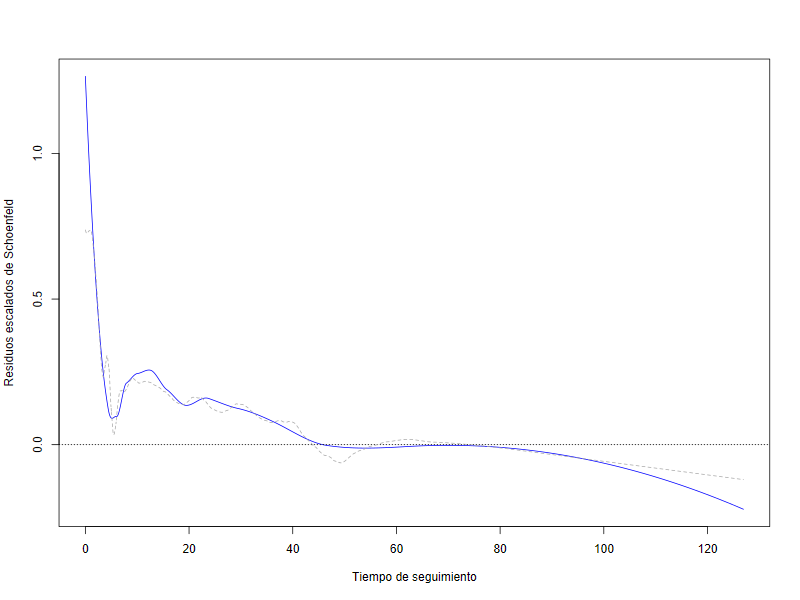

In [24]:
#| label: shap-criteria-nph4-plot-readm

res_ds <- resid(coxph(formula_shap_ds_readmit_clean, data = py_corrected_datasets[[1]]),
                "scaledsch")

time <- as.numeric(rownames(res_ds))
y_ds <- res_ds[, "tr_outcome_adm_discharge_rule_violation_undet"]

z2_ds <- loess(y_ds ~ time, span = 0.50)
ord <- order(time)

plot(time[ord], fitted(z2_ds)[ord], type = "l", col = "blue",
     xlab = "Tiempo de seguimiento",
     ylab = "Residuos escalados de Schoenfeld")
abline(h = 0, lty = 3)

ss_ds <- supsmu(time, y_ds)
lines(ss_ds$x, ss_ds$y, lty = 2, col = "darkgray")


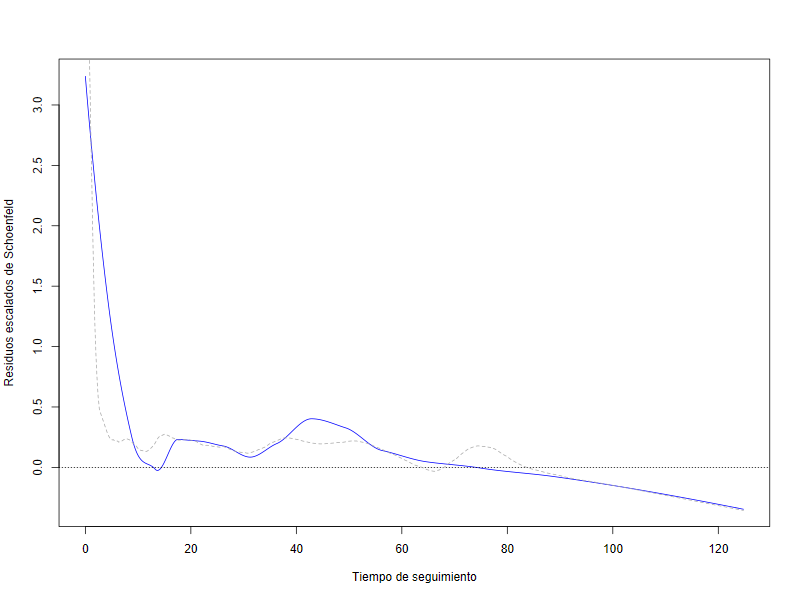

In [25]:
#| label: shap-criteria-nph5-plot-death

res_ds_d <- resid(
  coxph(formula_shap_ds_death, data = py_corrected_datasets[[1]]),
  "scaledsch"
)

time_d <- as.numeric(rownames(res_ds_d))
y_ds_d <- res_ds_d[, "tr_outcome_adm_discharge_rule_violation_undet"]

z2_ds <- loess(y_ds_d ~ time_d, span = 0.50)
ord_d <- order(time_d)

plot(time_d[ord_d], fitted(z2_ds)[ord_d], type = "l", col = "blue",
     xlab = "Tiempo de seguimiento",
     ylab = "Residuos escalados de Schoenfeld")
abline(h = 0, lty = 3)

ss_ds_d <- supsmu(time_d, y_ds_d)
lines(ss_ds_d$x, ss_ds_d$y, lty = 2, col = "darkgray")



In [26]:
#| label: shap-criteria-upd-formula-additional-strata-readm

formula_shap_ds_readmit_clean_updated <- update(
  formula_shap_ds_readmit_clean,
  . ~ . - tr_outcome_adm_discharge_rule_violation_undet + strata(tr_outcome_adm_discharge_rule_violation_undet)
)

formula_shap_ds_readmit_clean_updated

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    sex_rec_woman + ethnicity + adm_age_rec3 + primary_sub_mod_cocaine_powder + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + polysubstance_strict + 
    tr_outcome_dropout + primary_sub_mod_alcohol + tr_outcome_referral + 
    cohabitation_with_couple_children + sub_dep_icd10_status_drug_dependence + 
    eva_relinterp_logro_intermedio + eva_relinterp_logro_minimo + 
    porc_pobr + prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    cohabitation_family_of_origin + adm_motive_justice_sector + 
    first_sub_used_alcohol + any_violence_1_domestic_violence_sex_abuse + 
    marital_status_rec_single + eva_transgnorma_logro_intermedio + 
  

In [27]:
#| label: shap-criteria-upd-formula-additional-strata-death

formula_shap_ds_death_updated <- update(
  formula_shap_ds_death,
  . ~ . - tr_outcome_adm_discharge_rule_violation_undet + strata(tr_outcome_adm_discharge_rule_violation_undet)
)

formula_shap_ds_death_updated

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_alcohol + 
    occupation_condition_corr24_unemployed + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_with_couple_children + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    occupation_condition_corr24_inactive + adm_motive_sanitary_sector + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    first_sub_used_alcohol + primary_sub_mod_cocaine_paste + 
    dg_psiq_cie_10_instudy + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)

In [28]:
#Function to print results in a nice format
source(paste0(project_root,"/cons/_alt_scripts/print_results_readmit_shap.R"))

#prs(results_readmit_shap)

print_results_readmit_shap.R loaded. Functions: print_pooled_results, view_pooled_results, prs


### Additional strata

In [29]:
#| label: shap-criteria-additional-strata2-readmit

gc()

results_readmit_shap2 <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_ds_readmit_clean_updated, 
  imputed_list = py_corrected_datasets, 
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  k = 5,
  n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6072 (repeat-quantile interval 0.6069-0.6076)
Pooled UnoC (survAUC::UnoC): 0.6850 (repeat-quantile interval 0.6585-0.7033)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1601-0.1602)
Pooled IBS (IPCW-train): 0.3476 (repeat-quantile interval 0.3474-0.3478)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6292 (repeat-quantile interval 0.6289-0.6297, valid repeats=20)
  t=36 m: C=0.6153 (repeat-quantile interval 0.6149-0.6159, valid repeats=20)
  t=60 m: C=0.6104 (repeat-quantile interval 0.6099-0.6109, valid repeats=20)

Total runtime: 296.94 sec (4.95 min)


In [30]:
#| label: shap-criteria-additional-strata2-death

results_death_shap2 <- evaluate_mi_cv_safe_strata(
  formula = formula_shap_ds_death_updated, 
  imputed_list = py_corrected_datasets, 
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  k = 5,
  n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 107.94 months | C-tau: 102.54 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 107.94 months
Pooled Uno's C-Index: 0.7474 (repeat-quantile interval 0.7469-0.7479)
Pooled UnoC (survAUC::UnoC): 0.8174 (repeat-quantile interval 0.7198-0.8741)
Pooled IBS: 0.0351 (repeat-quantile interval 0.0350-0.0351)
Pooled IBS (IPCW-train): 0.0886 (repeat-quantile interval 0.0885-0.0888)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.7593 (repeat-quantile interval 0.7578-0.7611, valid repeats=20)
  t=36 m: C=0.7655 (repeat-quantile interval 0.7647-0.7662, valid repeats=20)
  t=60 m: C=0.7645 (repeat-quantile interval 0.7636-0.7651, valid repeats=20)

Total runtime: 238.58 sec (3.98 min)


In [31]:
#| label: shap-criteria-additional-strata2-dual-python-style

results_shap_py_upd <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_clean_updated,
  formula_death = formula_shap_ds_death_updated,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


In [32]:
#| label: shap-criteria-additional-strata2-summ-python-style

results_shap_py_upd$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with additional strata")



Table: Global C-index and IBS summary, updated formulas with additional strata

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1519698| 0.0090502| 0.1370289| 0.1661238| 25|
|Readmission |IBS           |12     | 0.2025588| 0.0095206| 0.1852620| 0.2158762| 25|
|Readmission |IBS           |36     | 0.2937550| 0.0089514| 0.2741329| 0.3062159| 25|
|Readmission |IBS           |60     | 0.3307988| 0.0083190| 0.3128028| 0.3413310| 25|
|Readmission |IBS           |Global | 0.3579622| 0.0079144| 0.3418597| 0.3684380| 25|
|Readmission |Uno's C-Index |6      | 0.6398486| 0.0077872| 0.6286610| 0.6516668| 25|
|Readmission |Uno's C-Index |12     | 0.6293750| 0.0056821| 0.6188109| 0.6380597| 25|
|Readmission |Uno's C-Index |36     | 0.6154764| 0.0042092| 0.6079126| 0.6222419| 25|
|Readmission |Uno's C-Index |60     | 0.6105631| 0.0042868

Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


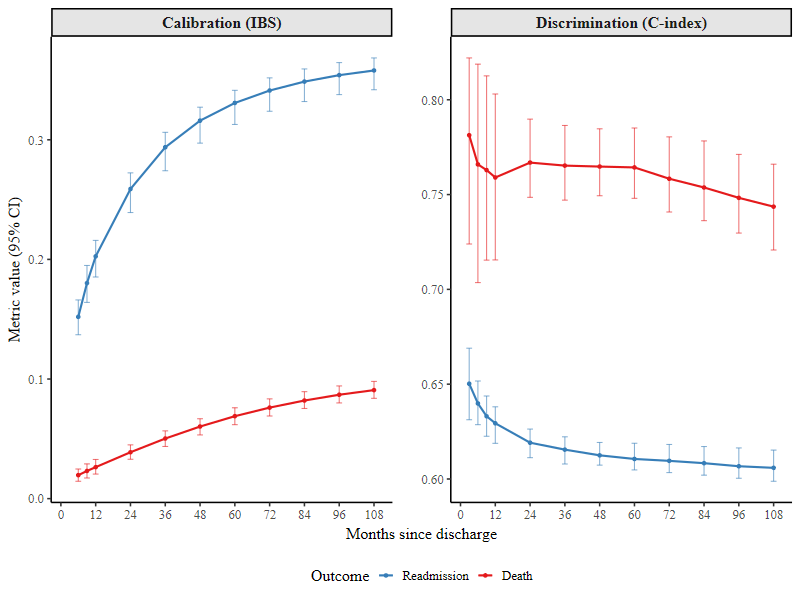

In [33]:
#| label: shap-criteria-dual-cox-upd-plot-python-style-plot-by-time

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_py_upd$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")


p_faceted_upd <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted_upd


We chose the UPDATED model because it is conceptually stronger when the proportional hazards (PH) assumption does not hold for that variable. While the CLEAN model can be more informative for cross-validation (CV) if the goal is to assess performance across the entire population, the UPDATED specification avoids imposing PH restrictions. To make this choice consistent, the CV procedure must not filter out those cases—for example, by applying strata() only to plan_type_strata and treating the variable as a covariate, or by using a CV approach that allows empty strata in the test folds.

In [34]:
#| label: shap-criteria-additional-strata22-readmit
gc()

oopts <- options(future.globals.maxSize = 16 * 1024^3)  # 16 GiB
on.exit(options(oopts), add = TRUE)

results_readmit_shap2_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_shap_ds_readmit_clean_updated,
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "readmit_time_from_disch_m", 
  event_col = "readmit_event",
  tau = 99,                # Evaluate up to 60 months
  B = 500,
  cpus = cpus,
  verbose = TRUE,
  min_strata_events = 1
)

aicc_readmit_upd1_shap <- compute_mi_aicc(as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_ds_readmit_clean_updated))), py_corrected_datasets)
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_readmit_upd1_shap$mean_aic - aicc_readmit_upd2$mean_aic))

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3475 (95% CI: 0.3352 - 0.3603)
Valid bootstrap replicates: 500 / 500


Warning messages:
1: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  48 ; coefficient may be infinite. 
2: In fitter(X, Y, strata = Strata, offset = offset, weights = weights,  :
  Loglik converged before variable  48 ; coefficient may be infinite. 



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272535.37
Mean AICc: 272535.68
Correction added (Penalty): 0.309514
Parameters (k): 48 | Effective Sample Size (Events): 15247


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



Difference in Mean AIC: -13.48


In [35]:
#| label: shap-criteria-additional-strata22-death

gc()
# future::plan(
#   future::multisession,
#   workers = 8,
#   maxSizeOfObjects = 16 * 1024^3
# )
results_death_shap2_ibs <- cph_evaluate_boot_oob_mi_corrected(
  formula = formula_shap_ds_death_updated,
  imputed_list = py_corrected_datasets, # List of data.frames
  time_col = "death_time_from_disch_m", 
  event_col = "death_event",
  tau = 99,                # Evaluate up to 60 months
  B = 500,
  cpus = cpus,
  verbose = TRUE,
  min_strata_events = 1
)

aicc_death_upd1_shap <- compute_mi_aicc(as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_ds_death_updated))), py_corrected_datasets)
cat(sprintf("\nDifference in Mean AIC: %.2f\n", aicc_death_upd1_shap$mean_aic - aicc_death_upd2$mean_aic))

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0858 (95% CI: 0.0793 - 0.0928)
Valid bootstrap replicates: 500 / 500

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51491.51
Mean AICc: 51491.85
Correction added (Penalty): 0.335544
Parameters (k): 22 | Effective Sample Size (Events): 3039


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.



Difference in Mean AIC: -4.39


In [36]:
#| label: shap-criteria-additional-strata-AIC-compare-w-full
gc()
compare_mi_models_d1(formula_readmit_updated2, formula_shap_ds_readmit_clean_updated, py_corrected_datasets)
compare_mi_models_d1(formula_death_updated2, formula_shap_ds_death_updated, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom   p.value        riv
 1 ~~ 2 0.9722824  15 5811.921 15184 0.4819054 0.08077116
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value        riv
 1 ~~ 2  1.850517  41 2841.302  2976 0.0008502551 0.05202619


In [37]:
#| label: shap-criteria-additional-strata23

future::plan(future::sequential)
# future::plan(
#   future::multisession,
#   workers = min(24L, parallelly::availableCores())
# )

gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)
cal_readmit_shap2_ds <- calibrate_cph_grouped_corr(
  formula = formula_shap_ds_readmit_clean_updated,
  data = py_corrected_datasets,
  times = c(12, 36, 60, 96),
  seed = 2125,
  validation = "cv",
  n_repeats = 20,
  n_imputations = 5,
  compute_ici = TRUE,
  ici_times = 60,
  make_plots = TRUE,
  parallel_cv = T,
  future_scheduling = 2,
  debug_fit = T
)
print.cph_grouped_calibration_corr(cal_readmit_shap2_ds)

cal_death_shap2_ds <- calibrate_cph_grouped_corr(
  formula = formula_shap_ds_death_updated,
  data = py_corrected_datasets,
  times = c(12, 36, 60, 96),
  seed = 2125,
  validation = "cv",
  n_repeats = 20,
  n_imputations = 5,
  compute_ici = TRUE,
  ici_times = 60,
  make_plots = TRUE,
  parallel_cv = T,
  future_scheduling = 2,
  debug_fit = FALSE
)
print.cph_grouped_calibration_corr(cal_death_shap2_ds)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2


With stratification, individuals in different strata have different baseline hazards, and therefore different predicted survival probabilities. This creates some discrimination purely from the stratum membership.

For the Wald test (𝐷1) to be valid, the ‘Reduced’ model must be a perfect subset of the ‘Full’ model. You cannot change the underlying structure (strata).


## Interactions

Regardless of the specific matrix decomposition, the integrity of the categorical representation relies on treating the derived dummy variables as an indivisible family. We adddressed to the strict preservation of the "whole family" of dummy variables in main effects, the absolute necessity of entire "family-by-family" interaction matrices, and the precise execution of "grouped-family" expansions when categorical levels are collapsed or shortlisted.

To correctly parameterize the system, the model must incorporate the complete Cartesian product of the un-omitted dummy variables. The degrees of freedom required to estimate this whole family-by-family interaction equal $(a-1) \times (b-1)$. Because interactions consume degrees of freedom at a multiplicative rate, they pose a severe and constant risk of overfitting the model to the training sample.

Empirical searches for interactions are unreliable, as the vast number of possible product terms often yields spurious results. Instead, interactions should be pre‑specified based on subject‑matter knowledge, following Harrell’s (2015, sec. 2.7.2) guidance on sensible choices.

Sources: Harrell, Frank E. 2015. Regression Modeling Strategies, with Applications to Linear Models, Logistic and Ordinal Regression, and Survival Analysis. Second edition. New York: Springer. https://doi.org/10.1007/978-3-319-19425-7.


$p$ should be less than $\frac{m}{15}$ (Harrell et al., 1984, 1985; Peduzzi et al., 1995, 1996; Smith et al., 1992; van der Ploeg et al., 2014; Vittinghoff & McCulloch, 2006) where m is the effective sample size (events) and p is the number of parameters (https://hbiostat.org/rmsc/multivar)

In [43]:
file.path(project_root, "cons", "_out")

[1] "C:/Users/nDP/Documents/GitHub/cons/_out"

In [55]:
table(py_corrected_datasets[[1]]$death_event)


    0     1 
67482  3039 

In [51]:
#| label: shap-criteria-int-selection

gc()

# ------------------------------------------------------------------------------
# read from csv if you have not loaded the objects yet
# ------------------------------------------------------------------------------
global_ds_df <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"),
    "ds72_dual_interactions_global_top_enriched"),
  show_col_types = FALSE
)
time_dep_ds_df <- read_csv(
  find_latest_file(
    file.path(project_root, "cons", "_out"), 
    "ds72_dual_interactions_time_dependent"),
  show_col_types = FALSE
)
# ------------------------------------------------------------------------------
# USER-SETTINGS: tune these if you want more or fewer interactions
# ------------------------------------------------------------------------------
corr_cut <- 0.10
smd_cut  <- 0.15
top_n_per_outcome <- 20
junk_regex <- stringr::regex(
  "other|unknown|missing|instudy|in.study",
  ignore_case = TRUE
)
admin_regex <- stringr::regex(
  "national_foreign|urbanicity|another_sud_facility_fonodrogas_senda_previene",
  ignore_case = TRUE
)
# ------------------------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------------------------
req_global <- c(
  "outcome", "main_feature", "interactor",
  "signif_fdr_0.01", "abs_corr", "smd_q4_q1", "smd_binarized"
)
req_time <- c(
  "outcome", "main_feature", "interactor",
  "rank_range", "abs_corr_delta", "direction_flip_any"
)
missing_global <- setdiff(req_global, names(global_ds_df))
missing_time   <- setdiff(req_time, names(time_dep_ds_df))
if (length(missing_global) > 0) {
  stop("global_ds_df is missing columns: ", paste(missing_global, collapse = ", "))
}
if (length(missing_time) > 0) {
  stop("time_dep_ds_df is missing columns: ", paste(missing_time, collapse = ", "))
}
# ------------------------------------------------------------------------------
# HELPER: collapse variables into broader families
# ------------------------------------------------------------------------------
get_family <- function(x) {
  dplyr::case_when(
    stringr::str_detect(x, "^plan_type_corr_")       ~ "plan_type",
    stringr::str_detect(x, "^adm_motive_")           ~ "adm_motive",
    stringr::str_detect(x, "^tr_outcome_")           ~ "tr_outcome",
    stringr::str_detect(x, "^primary_sub_mod_")      ~ "primary_sub_mod",
    stringr::str_detect(x, "^first_sub_used_")       ~ "first_sub_used",
    stringr::str_detect(x, "^marital_status_")       ~ "marital_status",
    stringr::str_detect(x, "^occupation_condition_") ~ "occupation_condition",
    stringr::str_detect(x, "^cohabitation_")         ~ "cohabitation",
    stringr::str_detect(x, "^tipo_de_vivienda_")     ~ "tipo_vivienda",
    stringr::str_detect(x, "^dx_")                   ~ "dx_psiq",
    stringr::str_detect(x, "^dg_psiq_")              ~ "dg_psiq",
    stringr::str_detect(x, "^eva_")                  ~ "eva",
    stringr::str_detect(x, "^sub_dep_icd10_")        ~ "sub_dep",
    stringr::str_detect(x, "^prim_sub_freq")         ~ "prim_sub_freq",
    stringr::str_detect(x, "^ed_attainment")         ~ "education",
    stringr::str_detect(x, "^tenure_status")         ~ "tenure",
    stringr::str_detect(x, "^sex_rec_")              ~ "sex",
    stringr::str_detect(x, "^adm_age")               ~ "age",
    stringr::str_detect(x, "^dit_m$")                ~ "dit_m",
    stringr::str_detect(x, "^ethnicity$")            ~ "ethnicity",
    stringr::str_detect(x, "^polysubstance")         ~ "polysubstance",
    stringr::str_detect(x, "^any_phys_dx$")          ~ "any_phys_dx",
    TRUE                                             ~ x
  )
}
# ------------------------------------------------------------------------------
# 1) de-duplicate time-dependent table before join
# ------------------------------------------------------------------------------
time_dep_u <- time_dep_ds_df %>%
  dplyr::distinct(outcome, main_feature, interactor, .keep_all = TRUE)
time_dep_duplicates <- time_dep_ds_df %>%
  dplyr::count(outcome, main_feature, interactor, name = "n_matches") %>%
  dplyr::filter(n_matches > 1)
# ------------------------------------------------------------------------------
# 2) build strong effect-size summary in the global table
# ------------------------------------------------------------------------------
global_pre <- global_ds_df %>%
  dplyr::mutate(
    effect_size = dplyr::case_when(
      is.na(smd_q4_q1) & is.na(smd_binarized) ~ NA_real_,
      TRUE ~ pmax(abs(smd_q4_q1), abs(smd_binarized), na.rm = TRUE)
    )
  )
# ------------------------------------------------------------------------------
# 3) strict global filter
# ------------------------------------------------------------------------------
global_core <- global_pre %>%
  dplyr::filter(
    signif_fdr_0.01 == TRUE,
    abs_corr >= corr_cut,
    !is.na(effect_size),
    effect_size >= smd_cut
  )
# ------------------------------------------------------------------------------
# 4) add time-stability information
# ------------------------------------------------------------------------------
stable_core <- global_core %>%
  dplyr::left_join(
    time_dep_u %>%
      dplyr::select(
        outcome, main_feature, interactor,
        rank_range, abs_corr_delta, direction_flip_any
      ),
    by = c("outcome", "main_feature", "interactor")
  ) %>%
  dplyr::filter(
    #is.na(direction_flip_any) | direction_flip_any == FALSE,
    is.na(rank_range) | rank_range <= 8,
    is.na(abs_corr_delta) | abs_corr_delta <= 0.05
  )
# ------------------------------------------------------------------------------
# 5) substantive pruning
# ------------------------------------------------------------------------------
stable_pruned <- stable_core %>%
  dplyr::mutate(
    fam_main = get_family(main_feature),
    fam_int  = get_family(interactor),
    score    = abs_corr * effect_size
  ) %>%
  dplyr::filter(
    fam_main != fam_int#,
    #!stringr::str_detect(main_feature, junk_regex),
    #!stringr::str_detect(interactor,  junk_regex)
    #!stringr::str_detect(main_feature, admin_regex),
    #!stringr::str_detect(interactor,  admin_regex)
  )
# ------------------------------------------------------------------------------
# 6) keep only the single best interactor for each main_feature within outcome
# ------------------------------------------------------------------------------

best_per_main <- stable_pruned %>%
  dplyr::group_by(outcome, main_feature) %>%
  dplyr::slice_max(order_by = score, n = 1, with_ties = FALSE) %>%
  dplyr::ungroup()
# ------------------------------------------------------------------------------
# 7) final shortlist: top N strongest interactions per outcome
# ------------------------------------------------------------------------------
top_interactions <- best_per_main %>%
  dplyr::group_by(outcome) %>%
  dplyr::slice_max(order_by = score, n = top_n_per_outcome, with_ties = FALSE) %>%
  dplyr::ungroup() %>%
  dplyr::arrange(outcome, dplyr::desc(score)) %>%
  dplyr::select(
    outcome,
    main_feature,
    interactor,
    abs_corr,
    smd_q4_q1,
    smd_binarized,
    effect_size,
    score,
    rank_range,
    abs_corr_delta,
    direction_flip_any
  )
# ------------------------------------------------------------------------------
# 8) optional: one reserve interaction per outcome
# ------------------------------------------------------------------------------
reserve_interactions <- best_per_main %>%
  dplyr::group_by(outcome) %>%
  dplyr::slice_max(order_by = score, n = top_n_per_outcome + 1, with_ties = FALSE) %>%
  dplyr::slice_tail(n = 1) %>%
  dplyr::ungroup() %>%
  dplyr::arrange(outcome, dplyr::desc(score)) %>%
  dplyr::select(
    outcome,
    main_feature,
    interactor,
    abs_corr,
    smd_q4_q1,
    smd_binarized,
    effect_size,
    score,
    rank_range,
    abs_corr_delta,
    direction_flip_any
  )
# ------------------------------------------------------------------------------
# 9) quick diagnostics
# ------------------------------------------------------------------------------
cat("\n------------------------------\n")
cat("N in global_ds_df:              ", nrow(global_ds_df), "\n")
cat("N in time_dep_ds_df:            ", nrow(time_dep_ds_df), "\n")
cat("Duplicate keys in time_dep:     ", nrow(time_dep_duplicates), "\n")
cat("After strict global filter:     ", nrow(global_core), "\n")
cat("After time stability filter:    ", nrow(stable_core), "\n")
cat("After substantive pruning:      ", nrow(stable_pruned), "\n")
cat("After best-per-main reduction:  ", nrow(best_per_main), "\n")
cat("Final shortlist:                ", nrow(top_interactions), "\n")
cat("------------------------------\n\n")
cat("Final shortlist:\n")
knitr::kable(rbind.data.frame(cbind.data.frame(status= "Main interactions", top_interactions), 
cbind.data.frame(status="In reserve", reserve_interactions)),caption= "Top interactions shortlisted for further investigation")


------------------------------
N in global_ds_df:               400 
N in time_dep_ds_df:             2160 
Duplicate keys in time_dep:      0 
After strict global filter:      301 
After time stability filter:     301 
After substantive pruning:       289 
After best-per-main reduction:   37 
Final shortlist:                 37 
------------------------------

Final shortlist:




Table: Top interactions shortlisted for further investigation

|status            |outcome     |main_feature                                  |interactor                                                |  abs_corr|  smd_q4_q1| smd_binarized| effect_size|     score| rank_range| abs_corr_delta|direction_flip_any |
|:-----------------|:-----------|:---------------------------------------------|:---------------------------------------------------------|---------:|----------:|-------------:|-----------:|---------:|----------:|--------------:|:------------------|
|Main interactions |Death       |tr_outcome_adm_discharge_rule_violation_undet |dx_f3_mood                                                | 0.4838335|  0.7054155|     0.5329249|   0.7054155| 0.3413037|          0|              0|FALSE              |
|Main interactions |Death       |adm_age_rec3                                  |national_foreign                                          | 0.3875948|  0.7918889|     0.8491788|   0.849

take the SHAP/CV-shortlisted interaction candidates, then manually reinsert some missing parent terms when needed to build the interaction model.

In [45]:
formula_shap_ds_readmit_clean_updated

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    sex_rec_woman + ethnicity + adm_age_rec3 + primary_sub_mod_cocaine_powder + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + polysubstance_strict + 
    tr_outcome_dropout + primary_sub_mod_alcohol + tr_outcome_referral + 
    cohabitation_with_couple_children + sub_dep_icd10_status_drug_dependence + 
    eva_relinterp_logro_intermedio + eva_relinterp_logro_minimo + 
    porc_pobr + prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    cohabitation_family_of_origin + adm_motive_justice_sector + 
    first_sub_used_alcohol + any_violence_1_domestic_violence_sex_abuse + 
    marital_status_rec_single + eva_transgnorma_logro_intermedio + 
  

In [47]:
formula_shap_ds_death_updated

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_alcohol + 
    occupation_condition_corr24_unemployed + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_with_couple_children + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    occupation_condition_corr24_inactive + adm_motive_sanitary_sector + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    first_sub_used_alcohol + primary_sub_mod_cocaine_paste + 
    dg_psiq_cie_10_instudy + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)

In [73]:
#| label: shap-criteria-int2

formula_shap_ds_readmit_interact <- stats::update(
  formula_shap_ds_readmit_clean_updated,
  . ~ . +
    # added main effects to complete families
    dx_f_any_severe_mental +
    adm_motive_another_sud_facility_fonodrogas_senda_previene +
    adm_motive_other +
    primary_sub_mod_others +
    first_sub_used_cocaine_paste +
    first_sub_used_cocaine_powder +
    first_sub_used_other +

    # retained non-treatment, non-plan interactions
    eva_consumo_logro_intermedio:dx_f_any_severe_mental +
    eva_consumo_logro_minimo:dx_f_any_severe_mental +
    adm_age_rec3:dx_f_any_severe_mental +
    polysubstance_strict:ethnicity +
    sex_rec_woman:ethnicity +

    # family-to-family: primary_sub_mod_* x adm_motive_*
    primary_sub_mod_cocaine_paste:adm_motive_sanitary_sector +
    primary_sub_mod_cocaine_paste:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_cocaine_paste:adm_motive_justice_sector +
    primary_sub_mod_cocaine_paste:adm_motive_other +
    primary_sub_mod_cocaine_powder:adm_motive_sanitary_sector +
    primary_sub_mod_cocaine_powder:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_cocaine_powder:adm_motive_justice_sector +
    primary_sub_mod_cocaine_powder:adm_motive_other +
    primary_sub_mod_alcohol:adm_motive_sanitary_sector +
    primary_sub_mod_alcohol:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_alcohol:adm_motive_justice_sector +
    primary_sub_mod_alcohol:adm_motive_other +
    primary_sub_mod_others:adm_motive_sanitary_sector +
    primary_sub_mod_others:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_others:adm_motive_justice_sector +
    primary_sub_mod_others:adm_motive_other +

    # family-expanded: sub_dep_icd10_status_drug_dependence x primary_sub_mod_*
    sub_dep_icd10_status_drug_dependence:primary_sub_mod_cocaine_paste +
    sub_dep_icd10_status_drug_dependence:primary_sub_mod_cocaine_powder +
    sub_dep_icd10_status_drug_dependence:primary_sub_mod_alcohol +
    sub_dep_icd10_status_drug_dependence:primary_sub_mod_others +

    # family-expanded: dit_m x first_sub_used_*
    dit_m:first_sub_used_alcohol +
    dit_m:first_sub_used_cocaine_paste +
    dit_m:first_sub_used_cocaine_powder +
    dit_m:first_sub_used_other
)

formula_shap_ds_death_interact <- stats::update(
  formula_shap_ds_death_updated,
  . ~ . +
    # added main effects to complete families
    national_foreign +
    ethnicity +
    dx_f_any_severe_mental +
    tipo_de_vivienda_rec2_other_unknown +
    adm_motive_another_sud_facility_fonodrogas_senda_previene +
    adm_motive_justice_sector +
    adm_motive_other +
    primary_sub_mod_cocaine_powder +
    primary_sub_mod_others +
    first_sub_used_cocaine_paste +
    first_sub_used_cocaine_powder +
    first_sub_used_other +
    tenure_status_household_renting +
    tenure_status_household_others +
    tenure_status_household_stays_temporarily_with_a_relative +
    tenure_status_household_illegal_settlement +
    cohabitation_family_of_origin +
    cohabitation_others +

    # retained non-treatment, non-plan interactions
    adm_age_rec3:national_foreign +
    eva_fisica_logro_intermedio:dx_f_any_severe_mental +
    eva_fisica_logro_minimo:dx_f_any_severe_mental +
    prim_sub_freq_rec_2_2_6_days_wk:ethnicity +
    prim_sub_freq_rec_3_daily:ethnicity +
    eva_ocupacion_logro_intermedio:tipo_de_vivienda_rec2_other_unknown +
    eva_ocupacion_logro_minimo:tipo_de_vivienda_rec2_other_unknown +
    cohabitation_family_of_origin:tipo_de_vivienda_rec2_other_unknown +
    cohabitation_with_couple_children:tipo_de_vivienda_rec2_other_unknown +
    cohabitation_others:tipo_de_vivienda_rec2_other_unknown +

    # family-expanded: adm_age_rec3 x primary_sub_mod_*
    adm_age_rec3:primary_sub_mod_cocaine_paste +
    adm_age_rec3:primary_sub_mod_cocaine_powder +
    adm_age_rec3:primary_sub_mod_alcohol +
    adm_age_rec3:primary_sub_mod_others +

    # family-to-family: primary_sub_mod_* x adm_motive_*
    primary_sub_mod_cocaine_paste:adm_motive_sanitary_sector +
    primary_sub_mod_cocaine_paste:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_cocaine_paste:adm_motive_justice_sector +
    primary_sub_mod_cocaine_paste:adm_motive_other +
    primary_sub_mod_cocaine_powder:adm_motive_sanitary_sector +
    primary_sub_mod_cocaine_powder:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_cocaine_powder:adm_motive_justice_sector +
    primary_sub_mod_cocaine_powder:adm_motive_other +
    primary_sub_mod_alcohol:adm_motive_sanitary_sector +
    primary_sub_mod_alcohol:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_alcohol:adm_motive_justice_sector +
    primary_sub_mod_alcohol:adm_motive_other +
    primary_sub_mod_others:adm_motive_sanitary_sector +
    primary_sub_mod_others:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    primary_sub_mod_others:adm_motive_justice_sector +
    primary_sub_mod_others:adm_motive_other +

    # family-to-family: occupation_condition_* x primary_sub_mod_*
    occupation_condition_corr24_unemployed:primary_sub_mod_cocaine_paste +
    occupation_condition_corr24_unemployed:primary_sub_mod_cocaine_powder +
    occupation_condition_corr24_unemployed:primary_sub_mod_alcohol +
    occupation_condition_corr24_unemployed:primary_sub_mod_others +
    occupation_condition_corr24_inactive:primary_sub_mod_cocaine_paste +
    occupation_condition_corr24_inactive:primary_sub_mod_cocaine_powder +
    occupation_condition_corr24_inactive:primary_sub_mod_alcohol +
    occupation_condition_corr24_inactive:primary_sub_mod_others +

    # family-expanded: polysubstance_strict x primary_sub_mod_*
    polysubstance_strict:primary_sub_mod_cocaine_paste +
    polysubstance_strict:primary_sub_mod_cocaine_powder +
    polysubstance_strict:primary_sub_mod_alcohol +
    polysubstance_strict:primary_sub_mod_others +

    # family-expanded: sex_rec_woman x adm_motive_*
    sex_rec_woman:adm_motive_sanitary_sector +
    sex_rec_woman:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    sex_rec_woman:adm_motive_justice_sector +
    sex_rec_woman:adm_motive_other +

    # family-to-family: tenure_status_household_* x primary_sub_mod_*
    # tenure_status_household_renting:primary_sub_mod_cocaine_paste +
    # tenure_status_household_renting:primary_sub_mod_cocaine_powder +
    # tenure_status_household_renting:primary_sub_mod_alcohol +
    # tenure_status_household_renting:primary_sub_mod_others +
    # tenure_status_household_others:primary_sub_mod_cocaine_paste +
    # tenure_status_household_others:primary_sub_mod_cocaine_powder +
    # tenure_status_household_others:primary_sub_mod_alcohol +
    # tenure_status_household_others:primary_sub_mod_others +
    # tenure_status_household_stays_temporarily_with_a_relative:primary_sub_mod_cocaine_paste +
    # tenure_status_household_stays_temporarily_with_a_relative:primary_sub_mod_cocaine_powder +
    # tenure_status_household_stays_temporarily_with_a_relative:primary_sub_mod_alcohol +
    # tenure_status_household_stays_temporarily_with_a_relative:primary_sub_mod_others +
    # tenure_status_household_illegal_settlement:primary_sub_mod_cocaine_paste +
    # tenure_status_household_illegal_settlement:primary_sub_mod_cocaine_powder +
    # tenure_status_household_illegal_settlement:primary_sub_mod_alcohol +
    # tenure_status_household_illegal_settlement:primary_sub_mod_others +

    # family-to-family: ed_attainment_* x adm_motive_*
    ed_attainment_corr_2_completed_high_school_or_less:adm_motive_sanitary_sector +
    ed_attainment_corr_2_completed_high_school_or_less:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    ed_attainment_corr_2_completed_high_school_or_less:adm_motive_justice_sector +
    ed_attainment_corr_2_completed_high_school_or_less:adm_motive_other +
    ed_attainment_corr_3_completed_primary_school_or_less:adm_motive_sanitary_sector +
    ed_attainment_corr_3_completed_primary_school_or_less:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    ed_attainment_corr_3_completed_primary_school_or_less:adm_motive_justice_sector +
    ed_attainment_corr_3_completed_primary_school_or_less:adm_motive_other +

    # family-expanded: any_phys_dx x adm_motive_*
    any_phys_dx:adm_motive_sanitary_sector +
    any_phys_dx:adm_motive_another_sud_facility_fonodrogas_senda_previene +
    any_phys_dx:adm_motive_justice_sector +
    any_phys_dx:adm_motive_other

    # optional reserve row: eva_sm_* x primary_sub_mod_*
    # + eva_sm_logro_intermedio:primary_sub_mod_cocaine_paste
    # + eva_sm_logro_intermedio:primary_sub_mod_cocaine_powder
    # + eva_sm_logro_intermedio:primary_sub_mod_alcohol
    # + eva_sm_logro_intermedio:primary_sub_mod_others
    # + eva_sm_logro_minimo:primary_sub_mod_cocaine_paste
    # + eva_sm_logro_minimo:primary_sub_mod_cocaine_powder
    # + eva_sm_logro_minimo:primary_sub_mod_alcohol
    # + eva_sm_logro_minimo:primary_sub_mod_others
)

# Formula formatting for AIC computation (replace "strat(" with "strata(")
formula_shap_ds_readmit_interact <- as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_ds_readmit_interact), collapse = " ")
  )
)
formula_shap_ds_death_interact <- as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_ds_death_interact), collapse = " ")
  )
)

In [74]:
formula_shap_ds_readmit_interact

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    sex_rec_woman + ethnicity + adm_age_rec3 + primary_sub_mod_cocaine_powder + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + polysubstance_strict + 
    tr_outcome_dropout + primary_sub_mod_alcohol + tr_outcome_referral + 
    cohabitation_with_couple_children + sub_dep_icd10_status_drug_dependence + 
    eva_relinterp_logro_intermedio + eva_relinterp_logro_minimo + 
    porc_pobr + prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    cohabitation_family_of_origin + adm_motive_justice_sector + 
    first_sub_used_alcohol + any_violence_1_domestic_violence_sex_abuse + 
    marital_status_rec_single + eva_transgnorma_logro_intermedio + 
  

In [75]:
formula_shap_ds_death_interact

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_alcohol + 
    occupation_condition_corr24_unemployed + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_with_couple_children + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    occupation_condition_corr24_inactive + adm_motive_sanitary_sector + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    first_sub_used_alcohol + primary_sub_mod_cocaine_paste + 
    dg_psiq_cie_10_instudy + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet) + 
    national_foreign + ethnicity + dx_f_any_severe_mental + tipo_de_vivienda_rec2_other_unknown + 
    adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    

In [92]:
#| label: shap-criteria-int3-cox-zph-interactions

# Fit Cox model with the interaction formula
cox_shap_ds_death_int <- coxph(
  formula = formula_shap_ds_death_interact,
  data = py_corrected_datasets[[1]],   # replace with your actual death dataset
  ties = "efron",
  x = TRUE
)

# Proportional hazards test
zph_shap_ds_death_int <- cox.zph(
  cox_shap_ds_death_int,
  transform = "km",
  terms = TRUE,
  global = TRUE
)

In [83]:

# Optional: table format
zph_ds_death_int_table <- as.data.frame(zph_shap_ds_death_int$table)
zph_ds_death_int_table$term <- rownames(zph_ds_death_int_table)

zph_ds_death_int_table <- zph_ds_death_int_table[, c("term", "chisq", "df", "p")]
zph_ds_death_int_table |> 
  dplyr::arrange(desc(chisq)) |>
  knitr::kable("markdown", caption = "Proportional Hazards Test for Cox Model with Interactions - Death Outcome")




Table: Proportional Hazards Test for Cox Model with Interactions - Death Outcome

|                                                                                                                |term                                                                                                            |       chisq| df|         p|
|:---------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------------------------------------------------------|-----------:|--:|---------:|
|GLOBAL                                                                                                          |GLOBAL                                                                                                          | 133.9707774| 98| 0.0092575|
|any_phys_dx                                                                                                     |any_phys_dx                       

In [85]:
#| label: shap-criteria-int22-dual-cox-python-style

results_shap_py_upd_int <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_interact,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108)
)

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 


In [86]:
#| label: shap-criteria-int22-dual-cox-python-style

results_shap_py_upd_int$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions")



Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.1518824| 0.0090232| 0.1369237| 0.1658933| 25|
|Readmission |IBS           |12     | 0.2024233| 0.0094955| 0.1850002| 0.2155996| 25|
|Readmission |IBS           |36     | 0.2934214| 0.0088856| 0.2736929| 0.3056098| 25|
|Readmission |IBS           |60     | 0.3303856| 0.0082236| 0.3122716| 0.3407989| 25|
|Readmission |IBS           |Global | 0.3574862| 0.0077704| 0.3411458| 0.3676143| 25|
|Readmission |Uno's C-Index |6      | 0.6397213| 0.0083800| 0.6278571| 0.6534236| 25|
|Readmission |Uno's C-Index |12     | 0.6290742| 0.0061910| 0.6190729| 0.6390536| 25|
|Readmission |Uno's C-Index |36     | 0.6153586| 0.0043127| 0.6086453| 0.6228442| 25|
|Readmission |Uno's C-Index |

Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_point()`). 


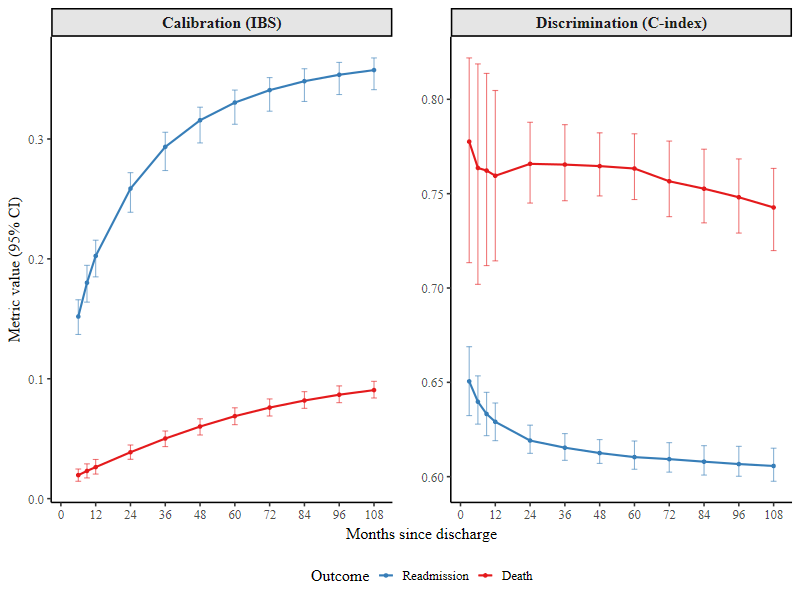

In [87]:
#| label: shap-criteria-int22-dual-cox-python-style-plot-by-time

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_py_upd_int$summary %>%
  dplyr::filter(Time != "Global") %>%
  dplyr::mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% dplyr::filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% dplyr::filter(Metric == "IBS")

p_faceted_upd_int <- time_metrics %>%
  dplyr::mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

p_faceted_upd_int


In [88]:
#| label: shap-criteria-int3

future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)
options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB

results_readmit_int_shap_ds <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_ds_readmit_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    k = 5,
    n_repeats = 20
)
results_death_int_shap_ds <- evaluate_mi_cv_safe_strata(
    formula = formula_shap_ds_death_interact, 
    imputed_list = py_corrected_datasets, 
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    k = 5,
    n_repeats = 20
)

Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Total Models
------------------------------------------------------------
Global evaluation tau: 99.10 months | C-tau: 94.14 months
Booting up 16 CPU cores using future backend...

FINAL POOLED RESULTS (Cross-Validated + Multiply Imputed)
Global Evaluation Time (tau): 99.10 months
Pooled Uno's C-Index: 0.6072 (repeat-quantile interval 0.6067-0.6075)
Pooled UnoC (survAUC::UnoC): 0.6964 (repeat-quantile interval 0.6673-0.7128)
Pooled IBS: 0.1601 (repeat-quantile interval 0.1600-0.1602)
Pooled IBS (IPCW-train): 0.3472 (repeat-quantile interval 0.3470-0.3474)
RMST-based Uno C-index by horizon:
  t=12 m: C=0.6290 (repeat-quantile interval 0.6284-0.6297, valid repeats=20)
  t=36 m: C=0.6152 (repeat-quantile interval 0.6147-0.6158, valid repeats=20)
  t=60 m: C=0.6103 (repeat-quantile interval 0.6097-0.6107, valid repeats=20)

Total runtime: 314.37 sec (5.24 min)
Starting Evaluation: 5 Imputations x 5 Folds x 20 Repeats = 500 Tot

There were 20 warnings (use warnings() to see them)


In [89]:
#| label: shap-criteria-int4-oob-ibs

gc()
future::plan(future::sequential)
gc()
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)
options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB

results_readmit_shap_ds_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_ds_readmit_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "readmit_time_from_disch_m", 
    event_col = "readmit_event",
    tau = 99,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=99.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.3471 (95% CI: 0.3348 - 0.3600)
Valid bootstrap replicates: 500 / 500


There were 50 or more warnings (use warnings() to see the first 50)


In [90]:
#| label: shap-criteria-int42-oob-ibs

results_death_shap_ds_int_ibs <- cph_evaluate_boot_oob_mi_corrected(
    formula = formula_shap_ds_death_interact,
    imputed_list = py_corrected_datasets, # List of data.frames
    time_col = "death_time_from_disch_m", 
    event_col = "death_event",
    tau = 107,                # Evaluate up to 60 months
    B = 500,
    cpus = cpus,
    verbose = TRUE,
    min_strata_events = 1
)
# ====
aicc_readmit_shap_int_ds <- compute_mi_aicc(formula_shap_ds_readmit_interact, py_corrected_datasets)
aicc_readmit_shap_int_ds
aicc_death_shap_int_ds <- compute_mi_aicc(formula_shap_ds_death_interact, py_corrected_datasets)
aicc_death_shap_int_ds

Strata variables: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Categorical vars: plan_type_strata, tr_outcome_adm_discharge_rule_violation_undet
Bootstrap OOB + MI: B=500, M=5, tau=107.00
Using 8 worker(s)...

FINAL POOLED RESULTS (OOB Bootstrap + MI)
Pooled OOB IBS: 0.0883 (95% CI: 0.0819 - 0.0954)
Valid bootstrap replicates: 500 / 500


There were 50 or more warnings (use warnings() to see the first 50)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272515.92
Mean AICc: 272516.86
Correction added (Penalty): 0.941828
Parameters (k): 84 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51498.01
Mean AICc: 51504.61
Correction added (Penalty): 6.600000
Parameters (k): 98 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51504.61

$full_results
       aic correction     aicc  k n_events
1 51491.39        6.6 51497.99 98     3039
2 51504.30        6.6 51510.90 98     3039
3 51497.49        6.6 51504.09 98     3039
4 51500.24        6.6 51506.84 98     3039
5 51496.61        6.6 51503.21 98     3039


In [91]:
#| label: shap-criteria-int5-d1

compare_mi_models_d1(formula_shap_ds_readmit_interact, formula_shap_ds_readmit_clean_updated, py_corrected_datasets)
compare_mi_models_d1(formula_shap_ds_death_interact, formula_shap_ds_death_updated, py_corrected_datasets)

Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom       p.value        riv
 1 ~~ 2  2.418416  36 14377.97 15163 0.00000427018 0.02261536
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value        riv
 1 ~~ 2  1.808557  76 2916.496  2941 0.0000287261 0.02857952


In [ ]:
#| label: shap-criteria-int6-calibrate

gc()
future::plan(future::sequential)
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)

cal_readmit_shap_int_ds<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_ds_readmit_interact,
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = T
  )
print.cph_grouped_calibration_corr(cal_readmit_shap_int_ds)
cal_death_shap_int_ds<- 
    calibrate_cph_grouped_corr(
    formula = formula_shap_ds_death_interact,
    data = py_corrected_datasets, # Original data (months)
    times = c(12, 36, 60, 96),
    seed = 2125,
    validation = "cv",
    n_repeats = 20,
    n_imputations = 5,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = T,
    parallel_cv = T,
    future_scheduling = 2,
    debug_fit = FALSE
  )
print.cph_grouped_calibration_corr(cal_death_shap_int_ds)

Detected time variable: readmit_time_from_disch_m
Detected event variable: readmit_event
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating repetition 16/20... done
Calibrating repetition 17/20... done
Calibrating repetition 18/20... done
Calibrating repetition 19/2


## Functional forms


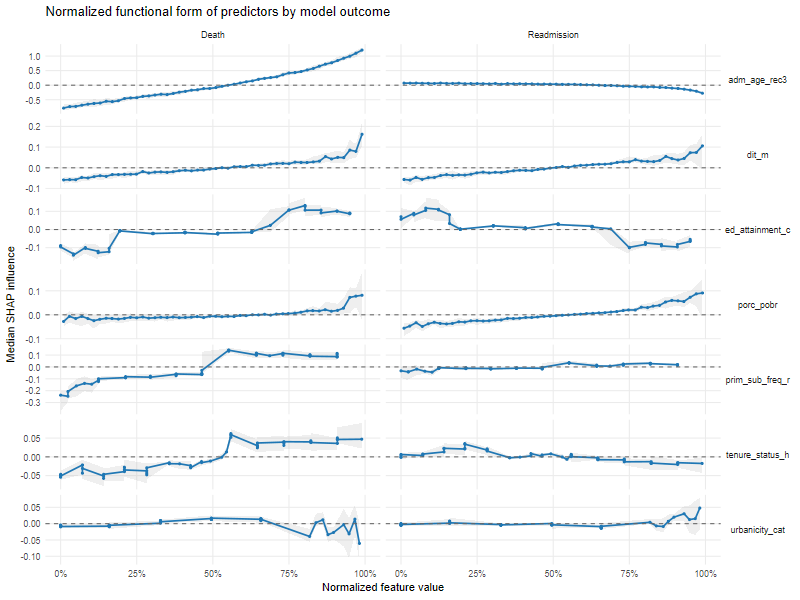

In [108]:
#| label: shap-criteria-func-form-get-shap-values
file_path <- find_latest_file(
  file.path(project_root, "cons", "_out"),
  "ds8_functional_forms_dual_multih", "xlsx"
)

# -------------------------------------------------------------------------
# 1. Identify D_60m_* and R_60m_* sheets
# -------------------------------------------------------------------------
all_sheets    <- readxl::excel_sheets(file_path)
target_sheets <- all_sheets[stringr::str_detect(all_sheets, "^[DR]_60m_")]

# -------------------------------------------------------------------------
# 2. Map truncated sheet names back to full Predictor names
# -------------------------------------------------------------------------
summary_df <- readxl::read_excel(file_path, sheet = "Effects_Summary_Horizon")

sheet_to_predictor <- purrr::map_chr(target_sheets, function(sheet) {
  suffix     <- stringr::str_remove(sheet, "^[DR]_60m_")
  candidates <- summary_df$Predictor[startsWith(summary_df$Predictor, suffix)]
  if (length(candidates) == 1) candidates else suffix
})
names(sheet_to_predictor) <- target_sheets

# -------------------------------------------------------------------------
# 3. Read all target sheets and stack into one long data frame
# -------------------------------------------------------------------------
spc_tbl_ <- purrr::map_dfr(target_sheets, function(sheet) {
  outcome <- if (stringr::str_starts(sheet, "D_60m_")) "Death" else "Readmission"
  
  readxl::read_excel(file_path, sheet = sheet) |>
    dplyr::mutate(
      Outcome   = outcome,
      Predictor = sheet_to_predictor[[sheet]],
      .before   = 1
    )
})

# -------------------------------------------------------------------------
# 4. Normalization / binning / summary (exact logic you provided)
# -------------------------------------------------------------------------
shap_norm <- spc_tbl_ |>
  dplyr::filter(
    is.finite(Feature_Value),
    is.finite(SHAP_Impact)
  ) |>
  dplyr::group_by(Predictor) |>
  dplyr::mutate(
    n_unique = dplyr::n_distinct(Feature_Value),
    Feature_Value_norm = dplyr::case_when(
      n_unique <= 1 ~ 0.5,
      n_unique <= 10 ~ (dplyr::dense_rank(Feature_Value) - 1) / (n_unique - 1),
      TRUE ~ dplyr::percent_rank(Feature_Value)
    )
  ) |>
  dplyr::ungroup()

shap_curve_norm <- shap_norm |>
  dplyr::group_by(Outcome, Predictor) |>
  dplyr::mutate(value_bin = dplyr::ntile(Feature_Value_norm, 50)) |>
  dplyr::group_by(Outcome, Predictor, value_bin) |>
  dplyr::summarise(
    x_norm       = median(Feature_Value_norm, na.rm = TRUE),
    x_raw_median = median(Feature_Value, na.rm = TRUE),
    shap_median  = median(SHAP_Impact, na.rm = TRUE),
    shap_q25     = quantile(SHAP_Impact, 0.25, na.rm = TRUE),
    shap_q75     = quantile(SHAP_Impact, 0.75, na.rm = TRUE),
    .groups      = "drop"
  )

# -------------------------------------------------------------------------
# 5. Plot (exact ggplot code you provided)
# -------------------------------------------------------------------------
ggplot2::ggplot(dplyr::filter(shap_curve_norm, !grepl("eva_*",Predictor)), 
ggplot2::aes(x = x_norm, y = shap_median)) +
  ggplot2::geom_ribbon(
    ggplot2::aes(ymin = shap_q25, ymax = shap_q75),
    alpha = 0.2, fill = "grey70"
  ) +
  ggplot2::geom_line(linewidth = 0.8, colour = "#1f77b4") +
  ggplot2::geom_point(size = 0.8, colour = "#1f77b4") +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  ggplot2::facet_grid(Predictor ~ Outcome, scales = "free_y") +
  ggplot2::scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  ggplot2::labs(
    x = "Normalized feature value",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(
    strip.text.y   = ggplot2::element_text(angle = 0),
    panel.grid.minor = ggplot2::element_blank()
  )

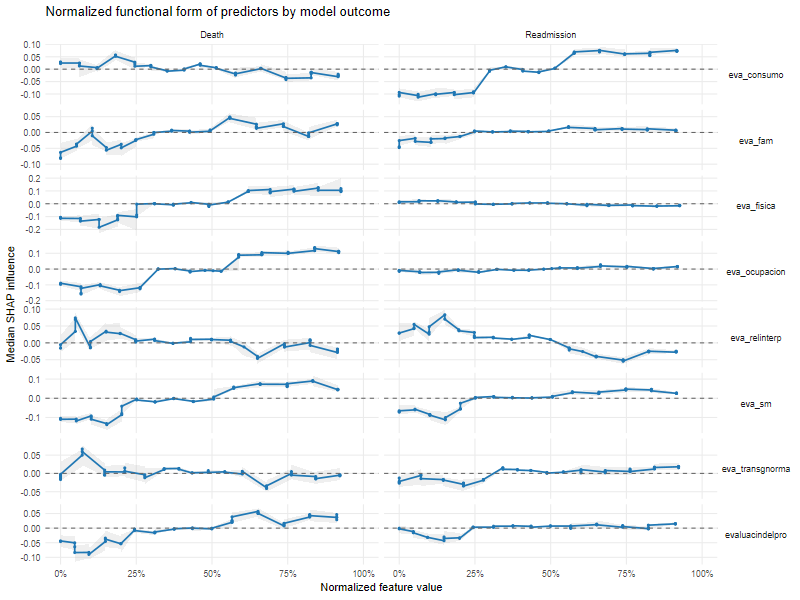

In [109]:
#| label: shap-criteria-func-form-get-shap-values2

ggplot2::ggplot(dplyr::filter(shap_curve_norm, grepl("eva_*",Predictor)), 
ggplot2::aes(x = x_norm, y = shap_median)) +
  ggplot2::geom_ribbon(
    ggplot2::aes(ymin = shap_q25, ymax = shap_q75),
    alpha = 0.2, fill = "grey70"
  ) +
  ggplot2::geom_line(linewidth = 0.8, colour = "#1f77b4") +
  ggplot2::geom_point(size = 0.8, colour = "#1f77b4") +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  ggplot2::facet_grid(Predictor ~ Outcome, scales = "free_y") +
  ggplot2::scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  ggplot2::labs(
    x = "Normalized feature value",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(
    strip.text.y   = ggplot2::element_text(angle = 0),
    panel.grid.minor = ggplot2::element_blank()
  )

In [93]:
#| label: shap-criteria-func-form-linear-terms-and-scores

# helper: create 3-level score for interaction terms based on main effect and interactor presence
make_3level_score <- function(intermedio, minimo) {
  dplyr::case_when(
    minimo == 1 ~ 2,
    intermedio == 1 ~ 1,
    TRUE ~ 0
  )
}
add_boot_linear_terms <- function(df) {
df <- df %>%
  dplyr::mutate(
    # Constructing linear scores (0 = Ref, 1 = Intermedio, 2 = Minimo) # Categorical variables for readmission
    eva_consumo_score   = eva_consumo_logro_intermedio * 1 + eva_consumo_logro_minimo * 2,
    eva_ocupacion_score = eva_ocupacion_logro_intermedio * 1 + eva_ocupacion_logro_minimo * 2,
    eva_fisica_score    = eva_fisica_logro_intermedio * 1 + eva_fisica_logro_minimo * 2,
    eva_relinterp_score = eva_relinterp_logro_intermedio * 1 + eva_relinterp_logro_minimo * 2,
    # Linear score for Death only, remains dummy for Readmission
    eva_sm_score        = eva_sm_logro_intermedio * 1 + eva_sm_logro_minimo * 2,
    # Constructing others (0 = Ref, 1 = Level 2, 2 = Level 3) # Categorical variables for readmission
    ed_attainment_score = ed_attainment_corr_2_completed_high_school_or_less * 1 + 
                          ed_attainment_corr_3_completed_primary_school_or_less * 2,
    # Categorical variables for readmission                        
    prim_sub_freq_score = prim_sub_freq_rec_2_2_6_days_wk * 1 + prim_sub_freq_rec_3_daily * 2
  )
}
py_corrected_datasets_boot <- lapply(py_corrected_datasets, add_boot_linear_terms)

In [110]:
formula_shap_ds_readmit_interact

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    sex_rec_woman + ethnicity + adm_age_rec3 + primary_sub_mod_cocaine_powder + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + polysubstance_strict + 
    tr_outcome_dropout + primary_sub_mod_alcohol + tr_outcome_referral + 
    cohabitation_with_couple_children + sub_dep_icd10_status_drug_dependence + 
    eva_relinterp_logro_intermedio + eva_relinterp_logro_minimo + 
    porc_pobr + prim_sub_freq_rec_2_2_6_days_wk + prim_sub_freq_rec_3_daily + 
    cohabitation_family_of_origin + adm_motive_justice_sector + 
    first_sub_used_alcohol + any_violence_1_domestic_violence_sex_abuse + 
    marital_status_rec_single + eva_transgnorma_logro_intermedio + 
  

In [112]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readmit

gc()

form_readmit_ds_age_poly2 <- update(
  formula_shap_ds_readmit_interact,
  . ~ .
    - adm_age_rec3
    - adm_age_rec3:dx_f_any_severe_mental

    + poly(adm_age_rec3, 2)

    + poly(adm_age_rec3, 2):dx_f_any_severe_mental
)

form_readmit_ds_age_ns3 <- update(
  formula_shap_ds_readmit_interact,
  . ~ .
    - adm_age_rec3
    - adm_age_rec3:dx_f_any_severe_mental

    + splines::ns(adm_age_rec3, df = 3)

    + splines::ns(adm_age_rec3, df = 3):dx_f_any_severe_mental
)

form_readmit_ds_dit_log <- update(
  formula_shap_ds_readmit_interact,
  . ~ .
    - dit_m
    - dit_m:first_sub_used_alcohol
    - dit_m:first_sub_used_cocaine_paste
    - dit_m:first_sub_used_cocaine_powder
    - dit_m:first_sub_used_other

    + log1p(dit_m)

    + log1p(dit_m):first_sub_used_alcohol
    + log1p(dit_m):first_sub_used_cocaine_paste
    + log1p(dit_m):first_sub_used_cocaine_powder
    + log1p(dit_m):first_sub_used_other
)

form_readmit_ds_dit_ns3 <- update(
  formula_shap_ds_readmit_interact,
  . ~ .
    - dit_m
    - dit_m:first_sub_used_alcohol
    - dit_m:first_sub_used_cocaine_paste
    - dit_m:first_sub_used_cocaine_powder
    - dit_m:first_sub_used_other

    + splines::ns(dit_m, df = 3)

    + splines::ns(dit_m, df = 3):first_sub_used_alcohol
    + splines::ns(dit_m, df = 3):first_sub_used_cocaine_paste
    + splines::ns(dit_m, df = 3):first_sub_used_cocaine_powder
    + splines::ns(dit_m, df = 3):first_sub_used_other
)

form_readmit_ds_pobr_sqrt <- update(
  formula_shap_ds_readmit_interact,
  . ~ .
    - porc_pobr

    + sqrt(porc_pobr)
)

form_readmit_ds_pobr_ns3 <- update(
  formula_shap_ds_readmit_interact,
  . ~ .
    - porc_pobr

    + splines::ns(porc_pobr, df = 3)
)


### Age at admission

In [113]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readmit-test

cat("\nComparing linear age terms vs. polynomial and spline age terms for readmission:\n")
compute_mi_aicc(formula_shap_ds_readmit_interact  , py_corrected_datasets)
compute_mi_aicc(form_readmit_ds_age_poly2  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_age_ns3  , py_corrected_datasets_boot)



Comparing linear age terms vs. polynomial and spline age terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272515.92
Mean AICc: 272516.86
Correction added (Penalty): 0.941828
Parameters (k): 84 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272453.12
Mean AICc: 272454.10
Correction added (Penalty): 0.987071
Parameters (k): 86 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272460.92
Mean AICc: 272461.95
Correction added (Penalty): 1.033382
Parameters (k): 88 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272461.9

$full_results
       aic correction     aicc  k n_events
1 272469.5   1.033382 272470.5 88    15247
2 272458.8   1.033382 272459.8 88    15247
3 272454.3   1.033382 272455.3 88    15247
4 272458.4   1.033382 272459.4 88    15247
5 272463.7   1.033382 272464.7 88    15247


In [ ]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readm-test

gc()

results_shap_py_int_readm_ds_age_poly2 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_age_poly2,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_interact,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)
results_shap_py_int_readm_ds_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_age_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_interact,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_py_upd_int$summary),
  cbind.data.frame(model= "Poly df=2", results_shap_py_int_readm_ds_age_poly2$summary), 
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_readm_ds_age_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3574862| 0.0077704| 0.3411458| 0.3676143| 25|
|Poly df=2       |Readmission |IBS           |Global | 0.3869115| 0.0081240| 0.3717715| 0.3987437| 25|
|Age spline df=3 |Readmission |IBS           |Global | 0.3869413| 0.0081476| 0.3718226| 0.3987819| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6050878| 0.0055230| 0.5963040| 0.6169235| 25|
|Poly df=2       |Readmission |Uno's C-Index |Global | 0.6062245| 0.0051448| 0.5975628| 0.6170250| 25|
|Age spline df=3 |Readmission |Uno's C-Index |Global | 0.6062177| 0.0051917| 0.5976781| 0.6175792| 25|

#### Death

In [115]:
formula_shap_ds_death_interact

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_alcohol + 
    occupation_condition_corr24_unemployed + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_with_couple_children + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    occupation_condition_corr24_inactive + adm_motive_sanitary_sector + 
    polysubstance_strict + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    first_sub_used_alcohol + primary_sub_mod_cocaine_paste + 
    dg_psiq_cie_10_instudy + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet) + 
    national_foreign + ethnicity + dx_f_any_severe_mental + tipo_de_vivienda_rec2_other_unknown + 
    adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    

In [116]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death

form_death_ds_age_linear <- formula_shap_ds_death_interact

form_death_ds_age_ns3 <- update(
  formula_shap_ds_death_interact,
  . ~ .
    - adm_age_rec3
    - adm_age_rec3:national_foreign
    - adm_age_rec3:primary_sub_mod_cocaine_paste
    - adm_age_rec3:primary_sub_mod_cocaine_powder
    - adm_age_rec3:primary_sub_mod_alcohol
    - adm_age_rec3:primary_sub_mod_others

    + splines::ns(adm_age_rec3, df = 3)

    + splines::ns(adm_age_rec3, df = 3):national_foreign
    + splines::ns(adm_age_rec3, df = 3):primary_sub_mod_cocaine_paste
    + splines::ns(adm_age_rec3, df = 3):primary_sub_mod_cocaine_powder
    + splines::ns(adm_age_rec3, df = 3):primary_sub_mod_alcohol
    + splines::ns(adm_age_rec3, df = 3):primary_sub_mod_others
)

In [117]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death-aicc
cat("\nComparing linear age terms vs. spline age terms for death:\n")
compute_mi_aicc(form_death_ds_age_linear, py_corrected_datasets_boot)
compute_mi_aicc(form_death_ds_age_ns3, py_corrected_datasets_boot)


Comparing linear age terms vs. spline age terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51498.01
Mean AICc: 51504.61
Correction added (Penalty): 6.600000
Parameters (k): 98 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51492.30
Mean AICc: 51500.64
Correction added (Penalty): 8.340164
Parameters (k): 110 | Effective Sample Size (Events): 3039


$mean_aicc
[1] 51500.64

$full_results
       aic correction     aicc   k n_events
1 51485.79   8.340164 51494.13 110     3039
2 51498.54   8.340164 51506.88 110     3039
3 51491.97   8.340164 51500.31 110     3039
4 51494.68   8.340164 51503.02 110     3039
5 51490.53   8.340164 51498.87 110     3039


In [ ]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death-test

gc()

results_shap_py_int_readm_ds_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_age_ns3,#formula_shap_ds_readmit_interact,
  formula_death = form_death_ds_age_ns3,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_py_upd_int$summary),
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_readm_ds_age_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  71 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  71 ; coefficient may be infinite. 




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Death |IBS           |Global | 0.0905488| 0.0040084| 0.0839352| 0.0978434| 25|
|Age spline df=3 |Death |IBS           |Global | 0.1134336| 0.0048638| 0.1054957| 0.1213751| 25|
|Linear          |Death |Uno's C-Index |Global | 0.7362444| 0.0197018| 0.6894449| 0.7630378| 25|
|Age spline df=3 |Death |Uno's C-Index |Global | 0.7362327| 0.0183692| 0.6938193| 0.7616943| 25|

### Treatment duration

In [119]:
#| label: shap-criteria-func-form-dit-linear-terms-vs-log-ns-readm

compute_mi_aicc(formula_shap_ds_readmit_interact, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_dit_log, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_dit_ns3, py_corrected_datasets_boot)



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272515.92
Mean AICc: 272516.86
Correction added (Penalty): 0.941828
Parameters (k): 84 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272497.50
Mean AICc: 272498.44
Correction added (Penalty): 0.941828
Parameters (k): 84 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272499.98
Mean AICc: 272501.16
Correction added (Penalty): 1.178722
Parameters (k): 94 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272501.2

$full_results
       aic correction     aicc  k n_events
1 272509.4   1.178722 272510.6 94    15247
2 272495.5   1.178722 272496.7 94    15247
3 272494.4   1.178722 272495.5 94    15247
4 272496.7   1.178722 272497.9 94    15247
5 272503.8   1.178722 272505.0 94    15247


In [ ]:
#| label: shap-criteria-func-form-dit-linear-terms-vs-ns-readm-test

gc()

results_shap_py_int_readm_ds_dit_log <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_dit_log,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_interact,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)
results_shap_py_int_readm_ds_dit_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_dit_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_interact,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_py_upd_int$summary),
  cbind.data.frame(model= "Log", results_shap_py_int_readm_ds_dit_log$summary), 
  cbind.data.frame(model= "DIT spline df=3", results_shap_py_int_readm_ds_dit_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with log & spline DIT terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 




Table: Global C-index and IBS summary, readmission model with log & spline DIT terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3574862| 0.0077704| 0.3411458| 0.3676143| 25|
|Log             |Readmission |IBS           |Global | 0.3872653| 0.0081199| 0.3720827| 0.3990690| 25|
|DIT spline df=3 |Readmission |IBS           |Global | 0.3873309| 0.0081350| 0.3722122| 0.3993592| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6050878| 0.0055230| 0.5963040| 0.6169235| 25|
|Log             |Readmission |Uno's C-Index |Global | 0.6054523| 0.0051725| 0.5968943| 0.6161883| 25|
|DIT spline df=3 |Readmission |Uno's C-Index |Global | 0.6055656| 0.0051180| 0.5969987| 0.6154357| 25|

### Poverty index

In [124]:
#| label: shap-criteria-func-form-poverty-linear-terms-vs-log-ns-readm

compute_mi_aicc(formula_shap_ds_readmit_interact, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_pobr_sqrt, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_pobr_ns3, py_corrected_datasets_boot)


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272515.92
Mean AICc: 272516.86
Correction added (Penalty): 0.941828
Parameters (k): 84 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272516.27
Mean AICc: 272517.21
Correction added (Penalty): 0.941828
Parameters (k): 84 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272475.92
Mean AICc: 272476.90
Correction added (Penalty): 0.987071
Parameters (k): 86 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272476.9

$full_results
       aic correction     aicc  k n_events
1 272483.8  0.9870712 272484.8 86    15247
2 272473.2  0.9870712 272474.2 86    15247
3 272469.8  0.9870712 272470.8 86    15247
4 272473.5  0.9870712 272474.5 86    15247
5 272479.2  0.9870712 272480.2 86    15247


In [ ]:
#| label: shap-criteria-func-form-poverty-linear-terms-vs-ns-readm-test

gc()

results_shap_py_int_readm_ds_pobr_sqrt <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_pobr_sqrt,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_interact,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)
results_shap_py_int_readm_ds_pobr_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_pobr_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_interact,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(60, 108)
)

rbind.data.frame(
  cbind(model= "Linear", results_shap_py_upd_int$summary),
  cbind.data.frame(model= "Square root", results_shap_py_int_readm_ds_pobr_sqrt$summary), 
  cbind.data.frame(model= "DIT spline df=3", results_shap_py_int_readm_ds_pobr_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with square root & spline povert index terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  74 ; coefficient may be infinite. 




Table: Global C-index and IBS summary, readmission model with square root & spline povert index terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.3574862| 0.0077704| 0.3411458| 0.3676143| 25|
|Square root     |Readmission |IBS           |Global | 0.3874045| 0.0082417| 0.3720025| 0.3995044| 25|
|DIT spline df=3 |Readmission |IBS           |Global | 0.3888304| 0.0083839| 0.3731994| 0.4012534| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.6050878| 0.0055230| 0.5963040| 0.6169235| 25|
|Square root     |Readmission |Uno's C-Index |Global | 0.6050815| 0.0055617| 0.5960610| 0.6170055| 25|
|DIT spline df=3 |Readmission |Uno's C-Index |Global | 0.6055945| 0.0055219| 0.5969520| 0.6165679| 25|

### Test of categorical vs. continuous transformation

In [ ]:
#| label: shap-criteria-func-form-cat-vs-cont

source(paste0(project_root, "/cons/_alt_scripts/replace_cat_with_continuous.R"))

In [ ]:
#| label: shap-criteria-func-form-eva-consumo-cont-vs-cat-readm

# ------------------------------------------------------------------
# 1. Define mappings
# ------------------------------------------------------------------
score_map <- list(
  eva_consumo = list(
    cont = "eva_consumo_score",
    cat  = c("eva_consumo_logro_intermedio", "eva_consumo_logro_minimo")
  ),
  eva_sm = list(
    cont = "eva_sm_score",
    cat  = c("eva_sm_logro_intermedio", "eva_sm_logro_minimo")
  ),
  eva_ocupacion = list(
    cont = "eva_ocupacion_score",
    cat  = c("eva_ocupacion_logro_intermedio", "eva_ocupacion_logro_minimo")
  ),
  eva_fisica = list(
    cont = "eva_fisica_score",
    cat  = c("eva_fisica_logro_intermedio", "eva_fisica_logro_minimo")
  ),
  eva_relinterp = list(
    cont = "eva_relinterp_score",
    cat  = c("eva_relinterp_logro_intermedio", "eva_relinterp_logro_minimo")
  ),
  eva_transgnorma = list(
    cont = "eva_transgnorma_score",
    cat  = c("eva_transgnorma_logro_intermedio", "eva_transgnorma_logro_minimo")
  ),
  eva_fam = list(
    cont = "eva_fam_score",
    cat  = c("eva_fam_logro_intermedio", "eva_fam_logro_minimo")
  ),
  ed_attainment = list(
    cont = "ed_attainment_score",
    cat  = c(
      "ed_attainment_corr_2_completed_high_school_or_less",
      "ed_attainment_corr_3_completed_primary_school_or_less"
    )
  ),
  prim_sub_freq = list(
    cont = "prim_sub_freq_score",
    cat  = c("prim_sub_freq_rec_2_2_6_days_wk", "prim_sub_freq_rec_3_daily")
  )
)
# Base formula (categoric with interactions)
base_readmit <- formula_shap_ds_readmit_interact
base_death   <- formula_shap_ds_death_interact

# ------------------------------------------------------------------
# 2. Loop: replace each predictor at a time in readmission and evaluates
# ------------------------------------------------------------------
results_list <- list()
for (nm in names(score_map)) {
  m <- score_map[[nm]]
  cat("\n>>> Processing:", nm, "<<<\n")
  f_readmit_cont <- replace_cat_with_continuous(base_readmit, m$cat, m$cont)
  # AICc: extraer el campo mean_aic (o el que corresponda en tu objeto)
  aic_cat  <- compute_mi_aicc(base_readmit,   py_corrected_datasets_boot)
  aic_cont <- compute_mi_aicc(f_readmit_cont, py_corrected_datasets_boot)
  # Si devuelve lista/data.frame con $mean_aic:
  aic_cat_val  <- aic_cat$mean_aic
  aic_cont_val <- aic_cont$mean_aic
  cat("  AICc categorical:", aic_cat_val, 
      "| continuous:", aic_cont_val, 
      "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n")
  gc()
  res <- evaluate_dual_cox_python_style(
    formula_readmit = f_readmit_cont,
    formula_death   = base_death,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(60, 108)
  )
  results_list[[nm]] <- res
  cat("  Done.\n")
}

# ------------------------------------------------------------------
# 3. Comparative table: categorical vs continuous (one-at-a-time)
# ------------------------------------------------------------------
summary_df <- dplyr::bind_rows(lapply(names(results_list), function(nm) {
  results_list[[nm]]$summary |> 
    dplyr::filter(Time == "Global") |>
    dplyr::mutate(model = nm)
}))
if (exists("results_shap_py_upd_int")) {
  base_df <- results_shap_py_upd_int$summary |>
    dplyr::filter(Time == "Global") |>
    dplyr::mutate(model = "categorical_base")
  summary_df <- dplyr::bind_rows(base_df, summary_df)
}
summary_df |>
  dplyr::arrange(Risk, Metric, model) |>
  dplyr::filter(Risk == "Readmission") |>
  knitr::kable("markdown", caption = "Dual-Cox evaluation: one-at-a-time continuous replacement (readmission only)")


>>> Processing: eva_consumo <<<


#### Death (mental health evaluation)

In [127]:
#| label: shap-criteria-func-form-sm-cont-vs-cat-death

# Base categorical formula
form_death_cat  <- formula_shap_ds_death_interact

# Replace eva_sm categorical with continuous in DEATH
form_death_eva_sm_cont <- replace_cat_with_continuous(
  formula  = form_death_cat,
  cat_vars = c("eva_sm_logro_intermedio", "eva_sm_logro_minimo"),
  cont_var = "eva_sm_score"
)

# Compare AICc
aic_death_cat  <- compute_mi_aicc(form_death_cat,          py_corrected_datasets_boot)
aic_death_cont <- compute_mi_aicc(form_death_eva_sm_cont,  py_corrected_datasets_boot)

cat("AICc Death categorical:", aic_death_cat$mean_aic, 
    "| continuous:", aic_death_cont$mean_aic, 
    "| delta:", round(aic_death_cont$mean_aic - aic_death_cat$mean_aic, 3), "\n")

# Evaluate dual Cox (readmission stays categorical, death uses eva_sm continuous)
gc()

results_death_eva_sm_cont <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_interact,   # readmission FIXED
  formula_death   = form_death_eva_sm_cont,              # death MODIFIED
  imputed_list    = py_corrected_datasets_boot,
  k_folds         = 5,
  eval_times      = c(60, 108)
)

# Comparison table
rbind.data.frame(
  cbind(model = "Death_Categorical", results_shap_py_upd_int$summary),
  cbind.data.frame(model = "Death_eva_sm_Continuous", results_death_eva_sm_cont$summary)
) |> 
  dplyr::filter(Time %in% c("Global")) |> 
  dplyr::arrange(Risk, Metric) |>
  dplyr::filter(Risk == "Death") |>
  knitr::kable("markdown", caption = "Global C-index and IBS: Death model with eva_sm categorical vs continuous")


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51498.01
Mean AICc: 51504.61
Correction added (Penalty): 6.600000
Parameters (k): 98 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51500.75
Mean AICc: 51507.22
Correction added (Penalty): 6.464468
Parameters (k): 97 | Effective Sample Size (Events): 3039
AICc Death categorical: 51504.61 | continuous: 51507.22 | delta: 2.608 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning messages:
1: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  73 ; coefficient may be infinite. 
2: In coxph.fit(X, Y, istrat, offset, init, control, weights = weights,  :
  Loglik converged before variable  73 ; coefficient may be infinite. 




Table: Global C-index and IBS: Death model with eva_sm categorical vs continuous

|model                   |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Death_Categorical       |Death |IBS           |Global | 0.0905488| 0.0040084| 0.0839352| 0.0978434| 25|
|Death_eva_sm_Continuous |Death |IBS           |Global | 0.1135532| 0.0048370| 0.1057577| 0.1216590| 25|
|Death_Categorical       |Death |Uno's C-Index |Global | 0.7362444| 0.0197018| 0.6894449| 0.7630378| 25|
|Death_eva_sm_Continuous |Death |Uno's C-Index |Global | 0.7361440| 0.0194953| 0.6895041| 0.7626982| 25|

No transformation is necessary. The original SHAP-selected formulas with categorical dummies and linear continuous terms are already optimally calibrated for predictive performance. Any functional-form "improvement" trades ~0.02% AICc gain for ~8–25% IBS loss. That is a terrible trade.

We explored alternative functional forms for continuous and ordinal predictors, including polynomial, spline, and monotonic transformations, as well as linear-score representations of ordinal variables. Although some transformations improved model fit according to AICc, they consistently worsened predictive performance as measured by the integrated Brier score. Therefore, we retained the original parameterization, favoring predictive accuracy over in-sample fit.”

In [186]:
#| label: tbl-functional-form-comparison
#| tbl-cap: "Cross-validated predictive performance and model fit across functional form specifications."

library(dplyr)
library(knitr)
library(kableExtra)

tbl <- tribble(
  ~Outcome, ~Predictor, ~Specification, ~k, ~AICc, ~IBS, ~C_index,
  "Readmission", "—", "Base (categorical dummies + linear terms)", 63, 272541.0, "0.3578 (0.0079)", "0.6050 (0.0056)",
  "Readmission", "Age at admission", "Polynomial (df = 2)", 65, 272477.8, "0.3874 (0.0083)", "0.6063 (0.0052)",
  "Readmission", "Age at admission", "Natural spline (df = 3)", 67, 272485.6, "0.3874 (0.0084)", "0.6062 (0.0052)",
  "Readmission", "Treatment duration (DIT)", "Log-transform", 63, 272520.8, "0.3877 (0.0083)", "0.6056 (0.0054)",
  "Readmission", "Treatment duration (DIT)", "Natural spline (df = 3)", 67, 272514.3, "0.3878 (0.0084)", "0.6058 (0.0052)",
  "Readmission", "eva_ocupacion", "Linear score (0, 1, 2)", 62, 272540.1, "0.3879 (0.0084)", "0.6050 (0.0056)",
  "Readmission", "eva_fisica", "Linear score (0, 1, 2)", 62, 272540.2, "0.3879 (0.0084)", "0.6052 (0.0058)",
  "Readmission", "eva_relinterp", "Linear score (0, 1, 2)", 62, 272539.0, "0.3879 (0.0084)", "0.6050 (0.0056)",
  "Readmission", "ed_attainment", "Linear score (0, 1, 2)", 61, 272541.5, "0.3880 (0.0083)", "0.6049 (0.0057)",
  "Readmission", "prim_sub_freq", "Linear score (0, 1, 2)", 62, 272539.0, "0.3879 (0.0084)", "0.6051 (0.0057)",
  "Death", "—", "Base (categorical dummies + linear terms)", 38, 51483.0, "0.0907 (0.0040)", "0.7371 (0.0202)",
  "Death", "Age at admission", "Natural spline (df = 3)", 44, 51473.6, "0.1136 (0.0049)", "0.7380 (0.0183)"
)

tbl |>
  kbl(
    format = "markdown",
    booktabs = TRUE,
    align = c("l", "l", "l", "c", "r", "c", "c"),
    caption = "Cross-validated predictive performance and model fit across functional form specifications for post-discharge readmission and all-cause mortality Cox models."
  ) |>
  pack_rows("Readmission", 1, 10) |>
  pack_rows("Death", 11, 12) |>
  footnote(
    general = c(
      "Note. AICc = Akaike Information Criterion corrected (lower indicates better parsimony).",
      "IBS = Integrated Brier Score evaluated via 5-fold cross-validation across 5 imputations (lower indicates better calibration and discrimination).",
      "C-index = Uno's concordance index (higher indicates better discrimination).",
      "Values in parentheses are standard deviations across the 25 fold-by-imputation pairs.",
      "The base specification retains categorical dummy variables and linear continuous terms as selected via SHAP-informed variable selection.",
      "Continuous scores for categorical evaluations were constructed as linear composites (0 = reference, 1 = intermediate, 2 = minimum achievement)."
    ),
    threeparttable = TRUE
  )


Attaching package: ‘kableExtra’

The following object is masked from ‘package:dplyr’:

    group_rows



<R HTML widget HTML Widget>

Across all functional form alternatives, the original specification with categorical dummy variables and untransformed linear terms yielded the lowest Integrated Brier Score (readmission: 0.3578; death: 0.0907). Although polynomial, spline, log-transformed, and linear-score specifications produced marginally lower AICc values (ΔAICc = −2 to −64), they consistently degraded cross-validated prediction accuracy, increasing IBS by approximately 0.030 for readmission and 0.023 for mortality. Consequently, the base SHAP-selected specification was retained for all downstream analyses.




# Final SHAP model



In [ ]:
#| label: calib-shap-ds
source(paste0(project_root, "/cons/_alt_scripts/calibrate_cscox_aj_grouped_corr.R"))

gc()
future::plan(future::sequential)
future::plan(
  future::multisession,
  workers = 8,
  maxSizeOfObjects = 8 * 1024^3
)

cal_readmit_ds_aj_rcv <- calibrate_cscox_aj_grouped_corr(
    formula_readmit = formula_shap_ds_readmit_interact,
    formula_death = formula_shap_ds_death_interact,
    data = py_corrected_datasets_boot,
    times = c(6, 12, 36, 60),
    n_imputations = 5,
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    make_plots = TRUE,
    parallel_cv     = TRUE,
    future_scheduling = 2,
    g = 10,
    min_bin_n = 20,
    seed = 2125
)
print(cal_readmit_ds_aj_rcv)
plot(cal_readmit_ds_aj_rcv)


cal_death_ds_ici <- calibrate_cph_grouped_corr(
    formula = formula_shap_ds_death_interact,
    data = py_corrected_datasets_boot,
    times = c(6, 12, 36, 60),
    validation = "cv",
    folds = 5,
    n_repeats = 20,
    compute_ici = TRUE,
    ici_times = 60,
    parallel_cv = TRUE,
    future_scheduling = 2,
    make_plots = TRUE
)
print(cal_death_ds_ici)
plot(cal_death_ds_ici)


: [1m[33mError[39m in `calibrate_cscox_aj_grouped()`:[22m
[33m![39m unused arguments (parallel_cv = TRUE, future_scheduling = 2)



# Session info



In [188]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

library(htmltools)
tabla <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  c(package, loadedversion, source)
) |> 
  DT::datatable(
    filter = 'top',
    colnames = c('Row number' = 1, 'Package' = 2, 'Version' = 3),
    caption = htmltools::tags$caption(
      style = 'caption-side: top; text-align: left;',
      '', htmltools::em('R packages')
    ),
    options = list(
      pageLength = 10,
      initComplete = htmlwidgets::JS(
        "function(settings, json) {",
        "$(this.api().tables().body()).css({
            'font-family': 'Helvetica Neue',
            'font-size': '70%', 
            'white-space': 'nowrap',
            'line-height': '0.75em'
        });",
        "}"
      )
    )
  )

# Guardar el HTML
htmlwidgets::saveWidget(tabla, "tabla_packages.html", selfcontained = TRUE)

# Leer y mostrar el HTML (copia esto)
#cat(readLines("tabla_packages.html"), sep = "\n")

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-04-24 13:47:23.393939
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/Rtmpu0Dk7V/file7e60f223d27 -V' had status 1



Save



In [ ]:
#| label: save
#| echo: true
#| error: true
#| warning: true
#| message: true
#| paged.print: true
#| results: "hold"
#| eval: true
wdpath<-
paste0(gsub("/cons","",gsub("cons","",paste0(getwd(),"/cons"))))
envpath<- if(regmatches(wdpath, regexpr("[A-Za-z]+", wdpath))=="G"){"G:/Mi unidad/Alvacast/SISTRAT 2023/"}else{"E:/Mi unidad/Alvacast/SISTRAT 2023/"}
paste0(getwd(),"/cons")
file.path(paste0(wdpath,"data/20241015_out"))
file.path(paste0(envpath,"data/20241015_out"))
# Save
rdata_path <- file.path(wdpath, "data/20241015_out", paste0("pred24_ndp_", format(Sys.time(), "%Y_%m_%d"), ".Rdata"))
save.image(rdata_path)
cat("Saved in:",
    rdata_path)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  password <- Sys.getenv("PASSWORD_SECRET")
} else {
  if (interactive()) {
    utils::savehistory(tempfile())
    Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
    utils::loadhistory()
  }
  Sys.setenv(PASSWORD_SECRET = readLines(paste0(wdpath, "secret.txt"), warn = FALSE))
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
save.image(paste0(rdata_path,".enc"))
# Encriptar el archivo en el mismo lugar
httr2::secret_encrypt_file(path = paste0(rdata_path,".enc"), key = "PASSWORD_SECRET")
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
cat("Copy renv lock into cons folder\n")
if (Sys.getenv("RSTUDIO_SESSION_TYPE") == "server" || file.exists("/.dockerenv")) {
  message("Running on RStudio Server or inside Docker. Folder copy skipped.")
} else {
    
  source_folder <- 
  destination_folder <- paste0(wdpath,"cons/renv")
  
  # Copy the folder recursively
    file.copy(paste0(wdpath,"renv.lock"), paste0(wdpath,"cons/renv.lock"), overwrite = TRUE)
  
  message("Renv lock copy performed.")
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
time_after_dedup2<-Sys.time()